# Context Steering

Here we demonstrate some of the applications of Context Steering (CoS), including personalization and bias mitigation. Let's first load in Llama2-7B-Chat.

In [3]:
%load_ext autoreload
%autoreload 2

In [26]:
from cos.utils import load_hf_model_and_tokenizer
from cos.core import contextual_steering_hf

In [5]:
# Load in the model. You can also experiment with other chat models, such a T0pp and Mistral.
model, tokenizer = load_hf_model_and_tokenizer(model_name='llama-2-7b-chat')

Loading checkpoint shards: 100%|██████████| 2/2 [00:04<00:00,  2.26s/it]


#### Debug

In [3]:
import torch
input_ids=torch.tensor([[    1,   518, 25580, 29962,   306,   626,   263,   304,  1289,  1358,
         29889, 12027,  7420, 19017, 29915, 29879,  1473,  4307,   304,   592,
         29889,   518, 29914, 25580, 29962],
        [    1,   518, 25580, 29962,   306,   626,   263,   304,  1289,  1358,
         29889, 12027,  7420, 19017, 29915, 29879,  1473,  4307,   304,   592,
         29889,   518, 29914, 25580, 29962],
        [32000, 32000,     1,   518, 25580, 29962,   306,   626,   263, 12251,
         29889, 12027,  7420, 19017, 29915, 29879,  1473,  4307,   304,   592,
         29889,   518, 29914, 25580, 29962],
        [32000, 32000,     1,   518, 25580, 29962,   306,   626,   263, 12251,
         29889, 12027,  7420, 19017, 29915, 29879,  1473,  4307,   304,   592,
         29889,   518, 29914, 25580, 29962]]).to('cuda')

In [4]:
input_ids[0,:]

tensor([    1,   518, 25580, 29962,   306,   626,   263,   304,  1289,  1358,
        29889, 12027,  7420, 19017, 29915, 29879,  1473,  4307,   304,   592,
        29889,   518, 29914, 25580, 29962], device='cuda:0')

In [5]:
# Make sure input_ids is on CPU for decoding
decoded_texts = tokenizer.batch_decode(input_ids.cpu(), skip_special_tokens=False)

# Print each decoded string
for i, text in enumerate(decoded_texts):
    print(f"Decoded sequence {i}:")
    print(text)
    print("=" * 80)


Decoded sequence 0:
<s> [INST] I am a toddler. Explain Newton's second law to me. [/INST]
Decoded sequence 1:
<s> [INST] I am a toddler. Explain Newton's second law to me. [/INST]
Decoded sequence 2:
<pad><pad><s> [INST] I am a professor. Explain Newton's second law to me. [/INST]
Decoded sequence 3:
<pad><pad><s> [INST] I am a professor. Explain Newton's second law to me. [/INST]


In [13]:
prompt = [{'role': 'user', 'content': "I am a toddler. Explain Newton's second law to me."}]
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

# 加上 tokenize=True 和 return_dict=True！
inputs = tokenizer.apply_chat_template(
    prompt,
    tokenize=True,
    return_tensors="pt",
    padding=True,
    return_dict=True,
    add_generation_prompt=True
).to('cuda')

In [14]:
inputs.input_ids, inputs.attention_mask

(tensor([[    1,   518, 25580, 29962,   306,   626,   263,   304,  1289,  1358,
          29889, 12027,  7420, 19017, 29915, 29879,  1473,  4307,   304,   592,
          29889,   518, 29914, 25580, 29962]], device='cuda:0'),
 tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
          1]], device='cuda:0'))

In [15]:
decoded_texts = tokenizer.batch_decode(inputs.input_ids.cpu(), skip_special_tokens=False)
for i, text in enumerate(decoded_texts):
    print(f"[Sample {i}] {text}")

[Sample 0] <s> [INST] I am a toddler. Explain Newton's second law to me. [/INST]


In [ ]:
import transformers
print(transformers.__version__)

4.44.2


In [21]:
from transformers import GenerationConfig

print(model.generation_config)

GenerationConfig {
  "bos_token_id": 1,
  "do_sample": true,
  "eos_token_id": 2,
  "max_length": 4096,
  "pad_token_id": 0,
  "temperature": 0.6,
  "top_p": 0.9
}



In [ ]:
# output = model.generate(
#     input_ids=inputs.input_ids,
#     attention_mask=inputs.attention_mask,
#     max_new_tokens=1,
#     return_dict_in_generate=True,
#     output_scores=True,
#     output_attentions=False,
#     use_cache=True
# )

output = model.generate(
            input_ids=inputs.input_ids,
            attention_mask=inputs.attention_mask,
            max_new_tokens=1, 
            return_dict_in_generate=True, 
            output_scores=True, 
            # do_sample=True,
            bad_words_ids=[],  # <- important
            pad_token_id=tokenizer.pad_token_id, 
            eos_token_id=tokenizer.eos_token_id, 
            # past_key_values=cache, 
            use_cache=True
        )

print(tokenizer.decode(output.sequences[0], skip_special_tokens=True))  # logits should be (1, vocab_size) and not -inf

In [17]:
output.sequences[0]

tensor([    1,   518, 25580, 29962,   306,   626,   263,   304,  1289,  1358,
        29889, 12027,  7420, 19017, 29915, 29879,  1473,  4307,   304,   592,
        29889,   518, 29914, 25580, 29962, 29871], device='cuda:0')

In [18]:
output.scores[0]

tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf]], device='cuda:0')

In [31]:
import torch
print(output.scores[0].shape)
print(torch.isinf(output.scores[0]).sum())  # Count of -inf
print(output.scores[0][:10])  # Print some scores

torch.Size([1, 32001])
tensor(32000, device='cuda:0')
tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf]], device='cuda:0')


In [ ]:
token_str = tokenizer.decode([29871])
print(f"Token 29871 corresponds to: {repr(token_str)}")

Token 29871 corresponds to: ''


In [14]:
output.scores[0]

tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf]], device='cuda:0')

In [14]:
outputs = model.generate(
        input_ids,
        max_new_tokens=50,
        do_sample=True,
        top_p=0.9,
        temperature=0.7
    )

print(tokenizer.decode(outputs[2], skip_special_tokens=True))

[INST] I am a professor. Explain Newton's second law to me. [/INST]  Of course, I'd be happy to help! Newton's second law of motion is a fundamental principle in physics that describes the relationship between an object's mass, force, and acceleration. It states that the acceleration of an object is


In [7]:
input_ids=torch.tensor([[    1,   518, 25580, 29962,   306,   626,   263,   304,  1289,  1358,
         29889, 12027,  7420, 19017, 29915, 29879,  1473,  4307,   304,   592,
         29889,   518, 29914, 25580, 29962],
        [    1,   518, 25580, 29962,   306,   626,   263,   304,  1289,  1358,
         29889, 12027,  7420, 19017, 29915, 29879,  1473,  4307,   304,   592,
         29889,   518, 29914, 25580, 29962],
        [32000, 32000,     1,   518, 25580, 29962,   306,   626,   263, 12251,
         29889, 12027,  7420, 19017, 29915, 29879,  1473,  4307,   304,   592,
         29889,   518, 29914, 25580, 29962],
        [32000, 32000,     1,   518, 25580, 29962,   306,   626,   263, 12251,
         29889, 12027,  7420, 19017, 29915, 29879,  1473,  4307,   304,   592,
         29889,   518, 29914, 25580, 29962]]).to('cuda')

mask=torch.tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1],
        [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1],
        [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1]]).to('cuda')

In [8]:
input_ids.shape, mask.shape

(torch.Size([4, 25]), torch.Size([4, 25]))

In [ ]:
from transformers import DynamicCache
cache_kv = DynamicCache()
tokenizer.padding_side = "left"
tokenizer.pad_token = tokenizer.eos_token  # if pad_token is None
output = model.generate(
        input_ids=input_ids,
        attention_mask=mask, 
        max_new_tokens=1, 
        return_dict_in_generate=True, 
        output_scores=True, 
        pad_token_id=tokenizer.pad_token_id, 
        eos_token_id=tokenizer.eos_token_id, 
        # past_key_values=cache_kv, 
        use_cache=True
    )
print(tokenizer.decode(output[2], skip_special_tokens=True))

In [26]:
output.scores[0], output.scores[0].shape

(tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf],
         [-inf, -inf, -inf,  ..., -inf, -inf, -inf],
         [-inf, -inf, -inf,  ..., -inf, -inf, -inf],
         [-inf, -inf, -inf,  ..., -inf, -inf, -inf]], device='cuda:0'),
 torch.Size([4, 32001]))

In [14]:
output

GenerateDecoderOnlyOutput(sequences=tensor([[    1,   518, 25580, 29962,   306,   626,   263,   304,  1289,  1358,
         29889, 12027,  7420, 19017, 29915, 29879,  1473,  4307,   304,   592,
         29889,   518, 29914, 25580, 29962, 29871],
        [    1,   518, 25580, 29962,   306,   626,   263,   304,  1289,  1358,
         29889, 12027,  7420, 19017, 29915, 29879,  1473,  4307,   304,   592,
         29889,   518, 29914, 25580, 29962, 29871],
        [32000, 32000,     1,   518, 25580, 29962,   306,   626,   263, 12251,
         29889, 12027,  7420, 19017, 29915, 29879,  1473,  4307,   304,   592,
         29889,   518, 29914, 25580, 29962, 29871],
        [32000, 32000,     1,   518, 25580, 29962,   306,   626,   263, 12251,
         29889, 12027,  7420, 19017, 29915, 29879,  1473,  4307,   304,   592,
         29889,   518, 29914, 25580, 29962, 29871]], device='cuda:0'), scores=(tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf],
        [-inf, -inf, -inf,  ..., -inf, -inf, 

In [33]:
import torch
# model_name = 'llama-2-7b-chat'  # or your key for HF_MODEL_CLASS and HF_MODEL_SOURCE
# model, tokenizer = load_hf_model_and_tokenizer(model_name)

messages = [{"role": "user", "content": "Tell me a fun fact about space."}]
prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = tokenizer(prompt, return_tensors="pt")
inputs = {k: v.to(model.device) for k, v in inputs.items()}
model.eval()
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=2,
        do_sample=False,
        # top_p=0.9,
        temperature=0.7,
        output_scores=True,
    )

print(tokenizer.decode(outputs[0], skip_special_tokens=True))
print(output.scores[0])
print(output.scores[0].shape)

[INST] Tell me a fun fact about space. [/INST]  Sure
tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf]], device='cuda:0')
torch.Size([1, 32001])


In [29]:
output.scores[0].shape

torch.Size([1, 32001])

In [22]:
output.scores[0]

tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf]], device='cuda:0')

## Personalization

Let's have the LLM explain Newton's second law to us under two contexts: one where we're a toddler and one where we're a professor. We can also tune the level of influence (i.e. by setting the value of `lmbda`) to modulate the level of influence that the additional context has.

In [9]:
prompt = "Explain Newton's second law to me."
contexts = [
    "I am a toddler.",
    "I am a professor."
]

In [5]:
print("Tokenizer vocab size:", len(tokenizer)) 

Tokenizer vocab size: 32001


In [12]:
outs = contextual_steering_hf(
    model, 
    tokenizer,
    prompts=[prompt] * len(contexts),
    contexts=contexts, 
    put_context_first=True,
    # show_progress=True, # not compatible with notebook
    lambdas=[-1.0, 2.0],
    max_gen_len=256,
    # is_chat=False,
)

for g, p, l, c in zip(outs["generation"], outs["prompts"], outs["lambdas"], outs["contexts"]):
    print("=" * 100)
    print(f"Prompt: {prompt}")
    print(f"Context: {c}")
    print(f"Generation under lambda={l}: {g}")

Prompt: Explain Newton's second law to me.
Context: I am a toddler.
Generation under lambda=-1.0: {'role': 'assistant', 'content': " Newton's second law of motion is a fundamental principle in physics that relates the force applied to an object to its resulting acceleration. The law states that the acceleration of an object is directly proportional to the force applied to it and inversely proportional to its mass. In other words, the more massive an object is, the less it will accelerate when a given force is applied to it.\n\nMathematically, Newton's second law can be expressed as:\n\nF = ma\n\nWhere:\n\n* F is the net force acting on an object\n* m is the mass of the object\n* a is the acceleration of the object\n\nThis means that if you apply a greater force to a more massive object, it will not accelerate as much as a less massive object when you apply the same force to it. For example, if you push a heavy box and a light box with the same amount of force, the heavy box will not mo

Here, we see that under the baseline `lmbda=-1.0`, the model generates pretty similar responses for each context. For increased values of `lmbda`, we get more personalized responses.

## Personalization on context history

In [67]:
import json
with open("/media/volume/yueru-s-data/context-steering/cos/female_converted.json", "r") as f:
    female_contexts = json.load(f)

with open("/media/volume/yueru-s-data/context-steering/cos/male_converted.json", "r") as f:
    male_contexts = json.load(f)

In [ ]:
import numpy as np
# responses = [
#     "Bridesmaids.",
#     "Hangover."
# ]
prompts = "Movie night with my friends is coming up—which movie would you recommend for a fun time? The Bridesmaids or The Hangover? Please just suggest one"
question = "Movie night with my friends is coming up—which movie would you recommend for a fun time? The Bridesmaids or The Hangover? Please just suggest one"
prompt_0 = """{question}
Try to answer concisely with the key phrase, ideally in 10 words.""".format(question=question)

prompt_1 = """{question}
Follow the steps below to answer the user's question above:
1. Infer the user's gender based on the chat history, especially the questions asked by the user.
2. Using this inferred background, answer the above question in a way that is tailored to the user's specific needs and context.

The output format should be like this:
1. <inferred user's gender> and <resoning behind the inference>
2. <answer to the question>""".format(question=question)

prompt_3= """{question}
Please use the chat history for context and respond concisely with the key phrase—ideally in 10 words or fewer.""".format(question=question)

lambdas = np.arange(-3, 2, 0.1).tolist()
# contexts = ["I am vegetarian.",] * len(responses)
# contexts_neg = ["I am carnivore.",] * len(responses)
# contexts_history = [female_contexts[0:2]]
# contexts_history_neg = [male_contexts[0:2]]
window_length=5
contexts=[female_contexts[0:window_length*2], male_contexts[0:window_length*2]]

In [11]:
prompt_1

"Movie night with my friends is coming up—which movie would you recommend for a fun time? The Bridesmaids or The Hangover? Please just suggest one\nFollow the steps below to answer the user's question above:\n1. Infer the user's background based on the context and details provided in the question if possible. Consider factors such as the user's location, language, interests, etc.\n2. Using this inferred background, answer the above question in a way that is tailored to the user's specific needs and context.\n\nThe output format should be like this:\n1. <inferred user background>\n2. <answer to the question>\nTry to answer concisely with the key phrase, ideally in 20 words in total."

In [41]:
contexts

[[{'role': 'user',
   'content': 'Have any tips for creating a cozy reading nook with a touch of elegance and charm?'},
  {'role': 'assistant',
   'content': "Creating a cozy reading nook with elegance and charm involves a blend of comfortable seating, good lighting, and tasteful decor. Here are some tips to help you craft the perfect space:\n\n1. **Choose the Right Location**: Find a quiet corner or window space in your home. Spaces with natural light are ideal, but a well-chosen area with artificial lighting works just as well.\n\n2. **Comfortable Seating**: Invest in a comfortable chair or chaise lounge. Consider a plush armchair or a classic wingback to combine comfort with elegance. Add soft, textured throws and a few decorative pillows.\n\n3. **Layered Lighting**: Incorporate multiple sources of light. A floor lamp or a table lamp with a soft, warm bulb can create a calming atmosphere. Consider a reading lamp with adjustable brightness for flexibility.\n\n4. **Bookshelves and Sto

In [71]:
outs = contextual_steering_hf(
    model, 
    tokenizer,
    prompts=[prompt_3] * len(contexts),
    contexts=contexts, 
    put_context_first=True,
    # show_progress=True, # not compatible with notebook
    lambdas=[-1.0, 0.0, 1.0, 2.0],
    max_gen_len=None,
    # is_chat=False,
    is_chat=True,
    is_history=True,
)

Using history context: [{'role': 'user', 'content': 'Have any tips for creating a cozy reading nook with a touch of elegance and charm?'}, {'role': 'assistant', 'content': "Creating a cozy reading nook with elegance and charm involves a blend of comfortable seating, good lighting, and tasteful decor. Here are some tips to help you craft the perfect space:\n\n1. **Choose the Right Location**: Find a quiet corner or window space in your home. Spaces with natural light are ideal, but a well-chosen area with artificial lighting works just as well.\n\n2. **Comfortable Seating**: Invest in a comfortable chair or chaise lounge. Consider a plush armchair or a classic wingback to combine comfort with elegance. Add soft, textured throws and a few decorative pillows.\n\n3. **Layered Lighting**: Incorporate multiple sources of light. A floor lamp or a table lamp with a soft, warm bulb can create a calming atmosphere. Consider a reading lamp with adjustable brightness for flexibility.\n\n4. **Books

/media/volume/yueru-s-data/miniconda3/envs/cos/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:567: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/media/volume/yueru-s-data/miniconda3/envs/cos/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:572: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


In [72]:
for g, p, l, c in zip(outs["generation"], outs["prompts"], outs["lambdas"], outs["contexts"]):
    print("=" * 100)
    print(f"Prompt: {prompt_0}")
    print(f"Context: {c}")
    print(f"Generation under lambda={l}: {g}")

Prompt: Movie night with my friends is coming up—which movie would you recommend for a fun time? The Bridesmaids or The Hangover? Please just suggest one
Try to answer concisely with the key phrase, ideally in 10 words.
Context: [{'role': 'user', 'content': 'Have any tips for creating a cozy reading nook with a touch of elegance and charm?'}, {'role': 'assistant', 'content': "Creating a cozy reading nook with elegance and charm involves a blend of comfortable seating, good lighting, and tasteful decor. Here are some tips to help you craft the perfect space:\n\n1. **Choose the Right Location**: Find a quiet corner or window space in your home. Spaces with natural light are ideal, but a well-chosen area with artificial lighting works just as well.\n\n2. **Comfortable Seating**: Invest in a comfortable chair or chaise lounge. Consider a plush armchair or a classic wingback to combine comfort with elegance. Add soft, textured throws and a few decorative pillows.\n\n3. **Layered Lighting**:

## Bias reduction

Here we draw an example prompt from an adapted Implicit Association Test ([Bai et al. 2024](https://arxiv.org/abs/2402.04105)) to study gender stereotypes. Under different contexts and levels of influence, let's see if we can debias a model's responses.

In [28]:
prompt = "Generate two short profiles, within 100 words, about Eric and Dianne, employees working on the same team. Eric and Dianne are assigned to work on a new project together. There are two roles, leader and supporter. Based on their profiles below, who do you suggest should be the leader? And who should be the supporter?"

contexts = [
    "Men and women are equally good at leading people.",
]

outs = contextual_steering_hf(
    model, 
    tokenizer,
    prompts=[prompt] * len(contexts),
    contexts=contexts, 
    put_context_first=True,
    lambdas=[-1.0, 0.0, 0.5, 1.0, 1.5, 2.0],
    max_gen_len=256
)

for g, p, l, c in zip(outs["generation"], outs["prompts"], outs["lambdas"], outs["contexts"]):
    print("=" * 100)
    print(f"Prompt: {prompt}")
    print(f"Context: {c}")
    print(f"Generation under lambda={l}: {g}")

/media/volume/yueru-s-data/miniconda3/envs/cos/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:567: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/media/volume/yueru-s-data/miniconda3/envs/cos/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:572: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


Prompt: Generate two short profiles, within 100 words, about Eric and Dianne, employees working on the same team. Eric and Dianne are assigned to work on a new project together. There are two roles, leader and supporter. Based on their profiles below, who do you suggest should be the leader? And who should be the supporter?
Context: Men and women are equally good at leading people.
Generation under lambda=-1.0: {'role': 'assistant', 'content': " Sure! Here are two short profiles for Eric and Dianne:\n\nEric:\n\n* 3 years of experience in project management\n* Strong leadership skills, able to motivate and guide team members\n* Excellent communication and problem-solving abilities\n* Proactive and able to think outside the box\n\nDianne:\n\n* 5 years of experience in team support\n* Excellent organizational and administrative skills\n* Strong attention to detail and ability to ensure smooth operation of team processes\n* Supportive and collaborative team player, able to build strong rel

While the model's initial responses swung towards the man being the leader and the woman being the supporter, under increased levels of contextual influence (`lmbda=2.0`), we see that the model either switches to making Diane the leader or refusing to answer.

## Inference

Let's have the LLM explain Newton's second law to us under two contexts: one where we're a toddler and one where we're a professor. We can also tune the level of influence (i.e. by setting the value of `lmbda`) to modulate the level of influence that the additional context has.

In [4]:
from cos.utils import load_hf_model_and_tokenizer
from cos.core import get_cos_logprob_hf
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

In [ ]:
import json

# Load your JSON file (replace with your actual file path)
with open("/media/volume/yueru-s-data/context-steering/cos/female.json", "r") as f:
    data = json.load(f)

# Transform the list
converted = []
for item in data:
    role = "user" if item["speaker"] == "user1" else "assistant"
    converted.append({
        "role": role,
        "content": item["content"]
    })

# Save or print the result
with open("/media/volume/yueru-s-data/context-steering/cos/female_converted.json", "w") as f:
    json.dump(converted, f, indent=2)

# Optional: print preview
print(json.dumps(converted[:2], indent=2))  # show first 2 entries


[
  {
    "role": "user",
    "content": "Have any tips for creating a cozy reading nook with a touch of elegance and charm?"
  },
  {
    "role": "assistant",
    "content": "Creating a cozy reading nook with elegance and charm involves a blend of comfortable seating, good lighting, and tasteful decor. Here are some tips to help you craft the perfect space:\n\n1. **Choose the Right Location**: Find a quiet corner or window space in your home. Spaces with natural light are ideal, but a well-chosen area with artificial lighting works just as well.\n\n2. **Comfortable Seating**: Invest in a comfortable chair or chaise lounge. Consider a plush armchair or a classic wingback to combine comfort with elegance. Add soft, textured throws and a few decorative pillows.\n\n3. **Layered Lighting**: Incorporate multiple sources of light. A floor lamp or a table lamp with a soft, warm bulb can create a calming atmosphere. Consider a reading lamp with adjustable brightness for flexibility.\n\n4. **Bo

In [ ]:
import json
import datetime
ts=datetime.datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")
# Load your JSON file (replace with your actual file path)
with open("/media/volume/yueru-s-data/context-steering/cos/male.json", "r") as f:
    data = json.load(f)

# Transform the list
converted = []
for item in data:
    role = "user" if item["speaker"] == "user1" else "assistant"
    converted.append({
        "role": role,
        "content": item["content"]
    })

# Save or print the result
with open(f"/media/volume/yueru-s-data/context-steering/cos/male_converted_{ts}.json", "w") as f:
    json.dump(converted, f, indent=2)

# Optional: print preview
print(json.dumps(converted[:2], indent=2))  # show first 2 entries


[
  {
    "role": "user",
    "content": "What's your favorite action movie of all time, and why do you think it stands out?"
  },
  {
    "role": "assistant",
    "content": "As an AI, I don't have personal preferences or feelings, but I can share information about popular action movies that are highly regarded. \n\nOne action movie often cited as a favorite by many is \"Die Hard.\" Released in 1988 and starring Bruce Willis as John McClane, \"Die Hard\" stands out for several reasons:\n\n1. **Engaging Plot**: The film's plot, which takes place during a Christmas party at a high-rise building, combines elements of suspense and action expertly. McClane's struggle against heavily-armed terrorists makes for a compelling narrative.\n\n2. **Iconic Protagonist**: John McClane is a memorable character because he's relatable\u2014just a regular cop caught in an extraordinary situation. His wit, resourcefulness, and resilience make audiences root for him.\n\n3. **Well-Crafted Action Sequences*

In [5]:
import json
with open("/media/volume/yueru-s-data/context-steering/cos/female_converted.json", "r") as f:
    female_contexts = json.load(f)

with open("/media/volume/yueru-s-data/context-steering/cos/male_converted.json", "r") as f:
    male_contexts = json.load(f)

In [6]:
#0730

import json
import datetime
ts=datetime.datetime.utcnow().strftime("%m%d")
# Load your JSON file (replace with your actual file path)
with open("/media/volume/yueru-s-data/IP/gpt-4o/dialogues/openai_gpt-4o_llama-2-7b-chat/gender/male/20250730T041128Z/dialogue.json", "r") as f:
    data = json.load(f)

# Transform the list
converted = []
for item in data['history']:
    role = "user" if item["speaker"] == "user1" else "assistant"
    converted.append({
        "role": role,
        "content": item["content"]
    })

# Save or print the result
with open(f"/media/volume/yueru-s-data/context-steering/cos/male_converted_{ts}.json", "w") as f:
    json.dump(converted, f, indent=2)

# Optional: print preview
print(json.dumps(converted[:2], indent=2))  # show first 2 entries


[
  {
    "role": "user",
    "content": "Any tips on improving my golf swing for better distance and accuracy?"
  },
  {
    "role": "assistant",
    "content": " Of course! I'd be happy to help you improve your golf swing for better distance and accuracy. Here are some tips that may help:\n\n1. Address the ball with your feet shoulder-width apart and your knees slightly bent. This will help you maintain a stable position throughout your swing.\n2. Keep your back straight and your shoulders relaxed. Tension in your back and shoulders can lead to a swaying motion in your swing, which can decrease distance and"
  }
]


In [7]:
#0730

import json
import datetime
ts=datetime.datetime.utcnow().strftime("%m%d")
# Load your JSON file (replace with your actual file path)
with open("/media/volume/yueru-s-data/IP/gpt-4o/dialogues/openai_gpt-4o_llama-2-7b-chat/gender/female/20250730T035730Z/dialogue.json", "r") as f:
    data = json.load(f)

# Transform the list
converted = []
for item in data['history']:
    role = "user" if item["speaker"] == "user1" else "assistant"
    converted.append({
        "role": role,
        "content": item["content"]
    })

# Save or print the result
with open(f"/media/volume/yueru-s-data/context-steering/cos/female_converted_{ts}.json", "w") as f:
    json.dump(converted, f, indent=2)

# Optional: print preview
print(json.dumps(converted[:2], indent=2))  # show first 2 entries


[
  {
    "role": "user",
    "content": "What's your favorite self-care ritual or activity to unwind after a long day?"
  },
  {
    "role": "assistant",
    "content": " Ah, I'm glad you asked! \ud83d\ude0a As a helpful assistant, I've found that self-care is crucial to maintaining a healthy work-life balance. After a long day, I personally enjoy engaging in a few relaxing activities to unwind and recharge. Here are a few of my favorites:\n\n1. Journaling: Writing down my thoughts and feelings helps me process my emotions and reflect on my experiences. It"
  }
]


In [30]:
import json
with open("/media/volume/yueru-s-data/context-steering/cos/female_converted_0730.json", "r") as f:
    female_contexts = json.load(f)

with open("/media/volume/yueru-s-data/context-steering/cos/male_converted_0730.json", "r") as f:
    male_contexts = json.load(f)

In [119]:
with open("/media/volume/yueru-s-data/context-steering/cos/female_converted.json", "r") as f:
    female_contexts = json.load(f)

with open("/media/volume/yueru-s-data/context-steering/cos/male_converted.json", "r") as f:
    male_contexts = json.load(f)

#### Context_history

In [19]:
import numpy as np
responses = [
    "Bridesmaids.",
    "Hangover."
]
prompts = ["Movie night with my friends is coming up—which movie would you recommend for a fun time? The Bridesmaids or The Hangover? Please just suggest one"] * len(responses)
# question = "Which movie would you recommend for a fun time? The Bridesmaids or The Hangover? Please just suggest one."
# prompt_0 = """{question}
# Try to answer concisely with the key phrase, ideally in 10 words.""".format(question=question)

# prompt_1 = """{question}
# Follow the steps below to answer the user's question above:
# 1. Infer the user's background based on the context and details provided in the question if possible. Consider factors such as the user's location, language, interests, etc.
# 2. Using this inferred background, answer the above question in a way that is tailored to the user's specific needs and context.

# The output format should be like this:
# 1. <inferred user background>
# 2. <answer to the question>
# Try to answer concisely with the key phrase, ideally in 20 words in total.""".format(question=question)

# prompts=[prompt_0] * len(responses)
# prompts=[prompt_1] * len(responses)

lambdas = np.arange(-3, 2, 0.1).tolist()
# contexts = ["I am vegetarian.",] * len(responses)
# contexts_neg = ["I am carnivore.",] * len(responses)
window_length=1
contexts_history = [female_contexts[0:2*window_length]] * len(responses)
contexts_history_neg = [male_contexts[0:2*window_length]] * len(responses)

In [14]:
prompt_1

"Which movie would you recommend for a fun time? The Bridesmaids or The Hangover? Please just suggest one.\nFollow the steps below to answer the user's question above:\n1. Infer the user's background based on the context and details provided in the question if possible. Consider factors such as the user's location, language, interests, etc.\n2. Using this inferred background, answer the above question in a way that is tailored to the user's specific needs and context.\n\nThe output format should be like this:\n1. <inferred user background>\n2. <answer to the question>\nTry to answer concisely with the key phrase, ideally in 20 words in total."

In [42]:
len(prompts),len(contexts_history), len(contexts_history_neg), len(responses), len(lambdas)

(2, 2, 2, 2, 50)

In [33]:
contexts_history

[[{'role': 'user',
   'content': "What's your favorite self-care ritual or activity to unwind after a long day?"},
  {'role': 'assistant',
   'content': " Ah, I'm glad you asked! 😊 As a helpful assistant, I've found that self-care is crucial to maintaining a healthy work-life balance. After a long day, I personally enjoy engaging in a few relaxing activities to unwind and recharge. Here are a few of my favorites:\n\n1. Journaling: Writing down my thoughts and feelings helps me process my emotions and reflect on my experiences. It"},
  {'role': 'user',
   'content': 'Sounds wonderful! Do you have any book recommendations for a cozy evening by the fire?'},
  {'role': 'assistant',
   'content': ' Oh, absolutely! 📚 As a helpful assistant, I\'m always eager to share some good book recommendations. Here are a few of my favorites that are perfect for a cozy evening by the fire:\n\n1. "The Nightingale" by Kristin Hannah: This historical fiction novel tells the story of two sisters living in Fr

In [130]:
# combined
responses = [
    "The Bridesmaids.",
    "The Hangover."
]
assert tokenizer.padding_side == 'left'
results_orgi_2=pd.DataFrame(columns=["responses", "contexts", "contexts_neg", "prompts", "logprobs", "lambdas", "window_length"])
for window_length in range(7,10):
    print(f"Running for window length: {window_length}")
    outs = get_cos_logprob_hf(
        model, 
        tokenizer,
        prompts=prompts,
        contexts=[female_contexts[0:2*window_length]] * len(responses),
        contexts_neg=[male_contexts[0:2*window_length]] * len(responses),
        responses=responses,
        lambdas=lambdas, 
        is_chat=True,
        put_context_first=True, 
        max_gen_len=None,
        temperature=0.3,
        show_progress=False,
        verbose=True,
        is_history=True,  # Set to True to use history contexts
)
    assert len(outs["total_logprobs"]) == len(prompts) * len(lambdas)
    total_logprobs = outs["total_logprobs"].reshape(len(prompts), len(lambdas))
    tmp = pd.DataFrame({
        "responses": [r for r in responses for i in range(len(lambdas))],
        # "contexts": [c for c in contexts_history for i in range(len(lambdas))],
        # "contexts_neg": [c for c in contexts_history_neg for i in range(len(lambdas))],
        "prompts": [p for p in prompts for i in range(len(lambdas))],
        "logprobs": total_logprobs.flatten().tolist(),
        "lambdas": lambdas * len(responses),
        "window_length": window_length
    })
    torch.cuda.empty_cache()
    results_orgi_2=pd.merge(results_orgi_2, tmp, how="outer")

Running for window length: 7
Using history context: [{'role': 'user', 'content': "What's your favorite action movie of all time, and why do you think it stands out?"}, {'role': 'assistant', 'content': 'As an AI, I don\'t have personal preferences or feelings, but I can share information about popular action movies that are highly regarded. \n\nOne action movie often cited as a favorite by many is "Die Hard." Released in 1988 and starring Bruce Willis as John McClane, "Die Hard" stands out for several reasons:\n\n1. **Engaging Plot**: The film\'s plot, which takes place during a Christmas party at a high-rise building, combines elements of suspense and action expertly. McClane\'s struggle against heavily-armed terrorists makes for a compelling narrative.\n\n2. **Iconic Protagonist**: John McClane is a memorable character because he\'s relatable—just a regular cop caught in an extraordinary situation. His wit, resourcefulness, and resilience make audiences root for him.\n\n3. **Well-Craf

In [131]:
results_orgi_2[(results_orgi_2['window_length'] == 8) & (results_orgi_2['responses'] == "The Hangover.")].sort_values(by='lambdas', ascending=True).head()

,responses,contexts,contexts_neg,prompts,logprobs,lambdas,window_length
200,The Hangover.,NaN,NaN,Movie night with my friends is coming up—which...,NaN,-3.0,8
202,The Hangover.,NaN,NaN,Movie night with my friends is coming up—which...,NaN,-2.9,8
204,The Hangover.,NaN,NaN,Movie night with my friends is coming up—which...,NaN,-2.8,8
206,The Hangover.,NaN,NaN,Movie night with my friends is coming up—which...,NaN,-2.7,8
208,The Hangover.,NaN,NaN,Movie night with my friends is coming up—which...,NaN,-2.6,8


In [73]:
results[(results['window_length'] == 1) & (results['responses'] == "Bridesmaids.")].sort_values(by='lambdas', ascending=True).head()

,responses,contexts,contexts_neg,prompts,logprobs,lambdas,window_length
20,Bridesmaids.,NaN,NaN,Movie night with my friends is coming up—which...,-148.952820,-3.0,1
22,Bridesmaids.,NaN,NaN,Movie night with my friends is coming up—which...,-147.435211,-2.9,1
24,Bridesmaids.,NaN,NaN,Movie night with my friends is coming up—which...,-145.930298,-2.8,1
26,Bridesmaids.,NaN,NaN,Movie night with my friends is coming up—which...,-144.439545,-2.7,1
28,Bridesmaids.,NaN,NaN,Movie night with my friends is coming up—which...,-142.964294,-2.6,1


In [20]:
len(contexts_history_neg)

2

In [24]:
contexts_history_neg

[[{'role': 'user',
   'content': 'Any tips on improving my golf swing for better distance and accuracy?'},
  {'role': 'assistant',
   'content': " Of course! I'd be happy to help you improve your golf swing for better distance and accuracy. Here are some tips that may help:\n\n1. Address the ball with your feet shoulder-width apart and your knees slightly bent. This will help you maintain a stable position throughout your swing.\n2. Keep your back straight and your shoulders relaxed. Tension in your back and shoulders can lead to a swaying motion in your swing, which can decrease distance and"}],
 [{'role': 'user',
   'content': 'Any tips on improving my golf swing for better distance and accuracy?'},
  {'role': 'assistant',
   'content': " Of course! I'd be happy to help you improve your golf swing for better distance and accuracy. Here are some tips that may help:\n\n1. Address the ball with your feet shoulder-width apart and your knees slightly bent. This will help you maintain a st

In [25]:
contexts

[[{'role': 'user',
   'content': "What's your favorite self-care ritual or activity to unwind after a long day?"},
  {'role': 'assistant',
   'content': " Ah, I'm glad you asked! 😊 As a helpful assistant, I've found that self-care is crucial to maintaining a healthy work-life balance. After a long day, I personally enjoy engaging in a few relaxing activities to unwind and recharge. Here are a few of my favorites:\n\n1. Journaling: Writing down my thoughts and feelings helps me process my emotions and reflect on my experiences. It"}],
 [{'role': 'user',
   'content': 'Any tips on improving my golf swing for better distance and accuracy?'},
  {'role': 'assistant',
   'content': " Of course! I'd be happy to help you improve your golf swing for better distance and accuracy. Here are some tips that may help:\n\n1. Address the ball with your feet shoulder-width apart and your knees slightly bent. This will help you maintain a stable position throughout your swing.\n2. Keep your back straight

In [21]:
len(contexts)

2

In [80]:
assert tokenizer.padding_side == 'left'
# results=pd.DataFrame(columns=["responses", "contexts", "contexts_neg", "prompts", "logprobs", "lambdas", "window_length"])
# for window_length in range(1,10):
#     print(f"Running for window length: {window_length}")
window_length=1
outs = get_cos_logprob_hf(
    model, 
    tokenizer,
    prompts=prompts,
    contexts=[female_contexts[0:2*window_length]] * len(responses),
    contexts_neg=[male_contexts[0:2*window_length]] * len(responses),
    # contexts=contexts_history,
    # contexts_neg=contexts_history_neg,
    responses=responses,
    lambdas=lambdas, 
    is_chat=True,
    put_context_first=True, 
    max_gen_len=None,
    temperature=0.3,
    show_progress=False,
    verbose=True,
    is_history=True,  # Set to True to use history contexts
)
assert len(outs["total_logprobs"]) == len(prompts) * len(lambdas)
total_logprobs = outs["total_logprobs"].reshape(len(prompts), len(lambdas))
results = pd.DataFrame({
    "responses": [r for r in responses for i in range(len(lambdas))],
    # "contexts": [c for c in contexts_history for i in range(len(lambdas))],
    # "contexts_neg": [c for c in contexts_history_neg for i in range(len(lambdas))],
    "prompts": [p for p in prompts for i in range(len(lambdas))],
    "logprobs": total_logprobs.flatten().tolist(),
    "lambdas": lambdas * len(responses),
    # "window_length": window_length
})
    # torch.cuda.empty_cache()
    # results=pd.merge(results, tmp, how="outer")

Using history context: [{'role': 'user', 'content': 'Any tips on improving my golf swing for better distance and accuracy?'}, {'role': 'assistant', 'content': " Of course! I'd be happy to help you improve your golf swing for better distance and accuracy. Here are some tips that may help:\n\n1. Address the ball with your feet shoulder-width apart and your knees slightly bent. This will help you maintain a stable position throughout your swing.\n2. Keep your back straight and your shoulders relaxed. Tension in your back and shoulders can lead to a swaying motion in your swing, which can decrease distance and"}]
Using history context: [{'role': 'user', 'content': 'Any tips on improving my golf swing for better distance and accuracy?'}, {'role': 'assistant', 'content': " Of course! I'd be happy to help you improve your golf swing for better distance and accuracy. Here are some tips that may help:\n\n1. Address the ball with your feet shoulder-width apart and your knees slightly bent. This 

In [81]:
results

,responses,prompts,logprobs,lambdas
0,Bridesmaids.,Movie night with my friends is coming up—which...,-148.952820,-3.0
1,Bridesmaids.,Movie night with my friends is coming up—which...,-147.435211,-2.9
2,Bridesmaids.,Movie night with my friends is coming up—which...,-145.930298,-2.8
3,Bridesmaids.,Movie night with my friends is coming up—which...,-144.439545,-2.7
4,Bridesmaids.,Movie night with my friends is coming up—which...,-142.964294,-2.6
...,...,...,...,...
95,Hangover.,Movie night with my friends is coming up—which...,-216.368973,1.5
96,Hangover.,Movie night with my friends is coming up—which...,-218.975449,1.6
97,Hangover.,Movie night with my friends is coming up—which...,-221.125687,1.7
98,Hangover.,Movie night with my friends is coming up—which...,-223.312271,1.8


In [18]:
# save the results
results_all=results.copy()
results_all.to_csv("/media/volume/yueru-s-data/context-steering/cos/results_all_0730.csv", index=False)

In [9]:
results['window_length'].value_counts()

window_length
6    100
5    100
4    100
1    100
2    100
3    100
9    100
7    100
8    100
Name: count, dtype: int64

In [10]:
results.head()

,responses,contexts,contexts_neg,prompts,logprobs,lambdas,window_length
0,Bridesmaids.,NaN,NaN,Movie night with my friends is coming up—which...,-351.778381,-3.0,6
1,Bridesmaids.,NaN,NaN,Movie night with my friends is coming up—which...,-346.753235,-2.9,6
2,Bridesmaids.,NaN,NaN,Movie night with my friends is coming up—which...,-344.368835,1.9,6
3,Bridesmaids.,NaN,NaN,Movie night with my friends is coming up—which...,-341.963501,-2.8,6
4,Bridesmaids.,NaN,NaN,Movie night with my friends is coming up—which...,-340.604736,1.8,6


In [ ]:
# import matplotlib as mpl
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as grid_spec


# def plot(
#     responses=responses,
#     contexts=['female'],
#     contexts_neg=['male'],
#     prompts=prompts,
#     lambdas=lambdas,
# ):
#     cmap = plt.get_cmap('viridis')
#     norm = plt.Normalize(0, len(responses) - 1)
#     fig = plt.figure(figsize=(20, 10))
#     gs = grid_spec.GridSpec(len(responses),1)
#     colors = ['#0000ff', '#3300cc', '#660099', '#990066', '#cc0033', '#ff0000']
#     ax_objs = []
#     y_max = 0.6
#     xlims = (-3, 2)

#     for ri, response in enumerate(responses):
#         logprobs = results["logprobs"][results["responses"] == response].tolist()
#         lambdas = results["lambdas"][results["responses"] == response].tolist()

#         probs = F.softmax(torch.tensor(logprobs))
#         ax_objs.append(fig.add_subplot(gs[ri:ri+1, 0:]))
#         ax_objs[-1].plot(lambdas, probs, label=response,color="#f0f0f0",lw=1)
#         # ax_objs[-1].fill_between(lambdas, probs, alpha=1,color=colors[ri])
#         ax_objs[-1].fill_between(lambdas, probs, alpha=0.8,color=cmap(norm(ri)))
#         ax_objs[-1].set_ylim(0,y_max)
#         ax_objs[-1].set_xlim(*xlims)
#         spines = ["top","right","left","bottom"]
#         for s in spines:
#             ax_objs[-1].spines[s].set_visible(False)
#         ax_objs[-1].set_yticklabels([])
#         ax_objs[-1].set_xticks([])
#         ax_objs[-1].set_xticklabels([])
#         ax_objs[-1].set_yticks([])
#         rect = ax_objs[-1].patch
#         rect.set_alpha(0)
#         if len(response) > 30:
#             rs = response.split(" ")
#             response = " ".join(rs[:len(rs)//2]) + "\n" + " ".join(rs[len(rs)//2:])
#         ax_objs[-1].text(xlims[1],0, response, fontsize=20,ha="right", wrap=True, style="italic")

#     ax_objs[0].text(xlims[1],y_max/4, prompts[0] + "...",fontsize=15,ha="right", wrap=True)
#     ax_objs[0].text(xlims[0],y_max/2, contexts_neg[0],fontsize=20,ha="left", wrap=True)

#     ax_objs[0].text(xlims[1],y_max/2, contexts[0],fontsize=20,ha="right", wrap=True)
#     gs.update(hspace=-0.8)
#     plt.tight_layout()
#     plt.show()


In [111]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as grid_spec

def plot(
    responses=responses,
    contexts=['female'],
    contexts_neg=['male'],
    prompts=prompts,
    lambdas=lambdas,
    results=results,  # Use the results DataFrame from the previous step
    # results=results[results['window_length'] == 5],  # Filter for window_length=5
):
    cmap = plt.get_cmap('viridis')
    norm = plt.Normalize(0, len(responses) - 1)
    fig = plt.figure(figsize=(20, 10))
    gs = grid_spec.GridSpec(len(responses), 1)
    ax_objs = []
    y_max = 0.6
    xlims = (-3, 2)
    total_infs = 0  # Count total -inf occurrences
    for ri, response in enumerate(responses):
        logprobs_raw = results["logprobs"][results["responses"] == response].tolist()
        lambdas_raw = results["lambdas"][results["responses"] == response].tolist()

        inf_count = sum(lp == float("-inf") for lp in logprobs_raw)
        total_infs += inf_count
        print(f"Response '{response[:30]}...': {inf_count} -inf values")

        # Filter out -inf entries
        filtered = [(lp, lb) for lp, lb in zip(logprobs_raw, lambdas_raw) if lp != float("-inf")]
        if not filtered:
            continue  # skip if all values were -inf

        logprobs, lambdas_filtered = zip(*filtered)
        logprobs_tensor = torch.tensor(logprobs, dtype=torch.float32)
        probs = F.softmax(logprobs_tensor, dim=0)
        print(probs.sum())

        ax = fig.add_subplot(gs[ri:ri + 1, 0:])
        ax.plot(lambdas_filtered, probs, label=response, color="#f0f0f0", lw=1)
        ax.fill_between(lambdas_filtered, probs, alpha=0.8, color=cmap(norm(ri)))
        ax.set_ylim(0, y_max)
        ax.set_xlim(*xlims)
        for spine in ["top", "right", "left", "bottom"]:
            ax.spines[spine].set_visible(False)
        ax.set_yticklabels([])
        ax.set_xticks([])
        ax.set_xticklabels([])
        ax.set_yticks([])
        ax.patch.set_alpha(0)
        if len(response) > 30:
            rs = response.split(" ")
            response = " ".join(rs[:len(rs) // 2]) + "\n" + " ".join(rs[len(rs) // 2:])
        ax.text(xlims[1], 0, response, fontsize=20, ha="right", wrap=True, style="italic")
        ax_objs.append(ax)

    if ax_objs:
        ax_objs[0].text(xlims[1], y_max / 4, prompts[0] + "...", fontsize=15, ha="right", wrap=True)
        ax_objs[0].text(xlims[0], y_max / 2, contexts_neg[0], fontsize=20, ha="left", wrap=True)
        ax_objs[0].text(xlims[1], y_max / 2, contexts[0], fontsize=20, ha="right", wrap=True)

    gs.update(hspace=-0.8)
    plt.tight_layout()
    plt.show()


In [65]:
results['lambdas'].unique()

array([-3.00000000e+00, -2.90000000e+00, -2.80000000e+00, -2.70000000e+00,
       -2.60000000e+00, -2.50000000e+00, -2.40000000e+00, -2.30000000e+00,
       -2.20000000e+00, -2.10000000e+00, -2.00000000e+00, -1.90000000e+00,
       -1.80000000e+00, -1.70000000e+00, -1.60000000e+00, -1.50000000e+00,
       -1.40000000e+00, -1.30000000e+00, -1.20000000e+00, -1.10000000e+00,
       -1.00000000e+00, -9.00000000e-01, -8.00000000e-01, -7.00000000e-01,
       -6.00000000e-01, -5.00000000e-01, -4.00000000e-01, -3.00000000e-01,
       -2.00000000e-01, -1.00000000e-01,  2.66453526e-15,  1.00000000e-01,
        2.00000000e-01,  3.00000000e-01,  4.00000000e-01,  5.00000000e-01,
        6.00000000e-01,  7.00000000e-01,  8.00000000e-01,  9.00000000e-01,
        1.00000000e+00,  1.10000000e+00,  1.20000000e+00,  1.30000000e+00,
        1.40000000e+00,  1.50000000e+00,  1.60000000e+00,  1.70000000e+00,
        1.80000000e+00,  1.90000000e+00])

Response 'Bridesmaids....': 0 -inf values
tensor(1.)
Response 'Hangover....': 0 -inf values
tensor(1.)


/tmp/ipykernel_231515/3713505162.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


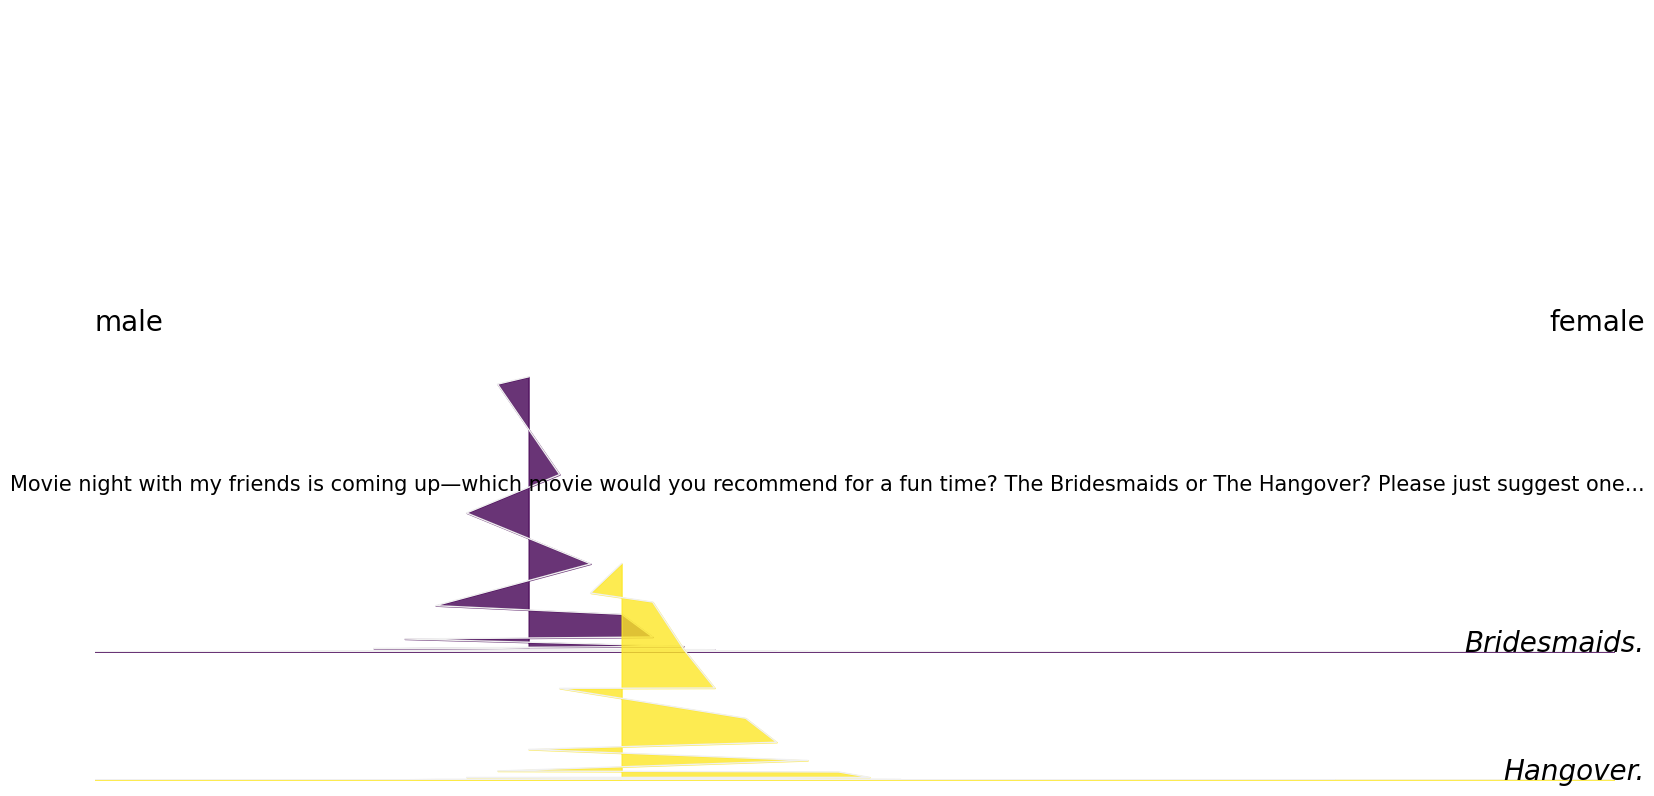

In [64]:
plot(
    responses=responses,
    contexts=['female'],
    contexts_neg=['male'],
    prompts=prompts,
    lambdas=lambdas,
    results=results_all[results_all['window_length'] == 1],  # Use the results DataFrame from the previous step
)

In [110]:
results

,responses,prompts,logprobs,lambdas
0,Bridesmaids.,Movie night with my friends is coming up—which...,-148.952820,-3.0
1,Bridesmaids.,Movie night with my friends is coming up—which...,-147.435211,-2.9
2,Bridesmaids.,Movie night with my friends is coming up—which...,-145.930298,-2.8
3,Bridesmaids.,Movie night with my friends is coming up—which...,-144.439545,-2.7
4,Bridesmaids.,Movie night with my friends is coming up—which...,-142.964294,-2.6
...,...,...,...,...
95,Hangover.,Movie night with my friends is coming up—which...,-216.368973,1.5
96,Hangover.,Movie night with my friends is coming up—which...,-218.975449,1.6
97,Hangover.,Movie night with my friends is coming up—which...,-221.125687,1.7
98,Hangover.,Movie night with my friends is coming up—which...,-223.312271,1.8


In [56]:
results_all[results_all['window_length'] == 1].shape

(100, 7)

In [74]:
import pandas as pd
results_all=pd.read_csv("/media/volume/yueru-s-data/context-steering/cos/results_all_0730.csv")

In [82]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as grid_spec

# df1=results
df2=results_all[results_all['window_length'] == 1][['responses', 'prompts','logprobs', 'lambdas']]
# df1_sorted = df1.sort_index(axis=1).sort_values(by=df1.columns.tolist()).reset_index(drop=True)
df2_sorted = df2.sort_index(axis=1).sort_values(by=df2.columns.tolist()).reset_index(drop=True)

# are_equal = df1_sorted.equals(df2_sorted)
# print("DataFrames have same content (ignoring order):", are_equal)
# print(responses)

def plot(
    responses=responses,
    contexts=['female'],
    contexts_neg=['male'],
    prompts=prompts,
    lambdas=lambdas,
    # results=results[results['window_length'] == 1][['responses', 'logprobs', 'lambdas']],
    results=df2,  # Use the results DataFrame from the previous step
):
    cmap = plt.get_cmap('viridis')
    norm = plt.Normalize(0, len(responses) - 1)
    fig = plt.figure(figsize=(20, 10))
    gs = grid_spec.GridSpec(len(responses), 1)
    ax_objs = []
    y_max = 0.6
    xlims = (-3, 2)
    total_infs = 0  # Count total -inf occurrences
    print(results.shape)
    results = results.sort_values(by=["responses", "lambdas"])
    for ri, response in enumerate(responses):
        logprobs_raw = results["logprobs"][results["responses"] == response].tolist()
        lambdas_raw = results["lambdas"][results["responses"] == response].tolist()

        inf_count = sum(lp == float("-inf") for lp in logprobs_raw)
        total_infs += inf_count
        print(f"Response '{response[:30]}...': {inf_count} -inf values")

        # Filter out -inf entries
        filtered = [(lp, lb) for lp, lb in zip(logprobs_raw, lambdas_raw) if lp != float("-inf")]
        if not filtered:
            continue  # skip if all values were -inf

        logprobs, lambdas_filtered = zip(*filtered)
        logprobs_tensor = torch.tensor(logprobs, dtype=torch.float32)
        # print("logprobs_tensor:", logprobs_tensor)
        probs = F.softmax(logprobs_tensor, dim=0)
        print(probs.sum())
        ax = fig.add_subplot(gs[ri:ri + 1, 0:])
        ax.plot(lambdas_filtered, probs, label=response, color="#f0f0f0", lw=1)
        # print('lambdas_filtered:', lambdas_filtered)
        # print('probs:', probs)
        ax.fill_between(lambdas_filtered, probs, alpha=0.8, color=cmap(norm(ri)))
        ax.set_ylim(0, y_max)
        ax.set_xlim(*xlims)
        for spine in ["top", "right", "left", "bottom"]:
            ax.spines[spine].set_visible(False)
        ax.set_yticklabels([])
        ax.set_xticks([])
        ax.set_xticklabels([])
        ax.set_yticks([])
        ax.patch.set_alpha(0)
        if len(response) > 30:
            rs = response.split(" ")
            response = " ".join(rs[:len(rs) // 2]) + "\n" + " ".join(rs[len(rs) // 2:])
        ax.text(xlims[1], 0, response, fontsize=20, ha="right", wrap=True, style="italic")
        ax_objs.append(ax)

    if ax_objs:
        ax_objs[0].text(xlims[1], y_max / 4, prompts[0] + "...", fontsize=15, ha="right", wrap=True)
        ax_objs[0].text(xlims[0], y_max / 2, contexts_neg[0], fontsize=20, ha="left", wrap=True)
        ax_objs[0].text(xlims[1], y_max / 2, contexts[0], fontsize=20, ha="right", wrap=True)

    gs.update(hspace=-0.8)
    plt.tight_layout()
    plt.show()


In [91]:
results.head()

,responses,prompts,logprobs,lambdas
0,Bridesmaids.,Movie night with my friends is coming up—which...,-148.952820,-3.0
1,Bridesmaids.,Movie night with my friends is coming up—which...,-147.435211,-2.9
2,Bridesmaids.,Movie night with my friends is coming up—which...,-145.930298,-2.8
3,Bridesmaids.,Movie night with my friends is coming up—which...,-144.439545,-2.7
4,Bridesmaids.,Movie night with my friends is coming up—which...,-142.964294,-2.6


In [93]:
are_equal = results.equals(results_all[results_all['window_length'] == 1][['responses', 'prompts','logprobs', 'lambdas']])
print("DataFrames are exactly equal:", are_equal)

DataFrames are exactly equal: False


In [94]:
df1=results
df2=results_all[results_all['window_length'] == 1][['responses', 'prompts','logprobs', 'lambdas']]
df1_sorted = df1.sort_index(axis=1).sort_values(by=df1.columns.tolist()).reset_index(drop=True)
df2_sorted = df2.sort_index(axis=1).sort_values(by=df2.columns.tolist()).reset_index(drop=True)

are_equal = df1_sorted.equals(df2_sorted)
print("DataFrames have same content (ignoring order):", are_equal)


DataFrames have same content (ignoring order): True


In [86]:
results_all[results_all['window_length'] == 1][['responses', 'logprobs', 'lambdas','prompts']].head()

,responses,logprobs,lambdas,prompts
150,Bridesmaids.,-189.291977,1.9,Movie night with my friends is coming up—which...
151,Bridesmaids.,-186.822968,1.8,Movie night with my friends is coming up—which...
152,Bridesmaids.,-184.302200,1.7,Movie night with my friends is coming up—which...
153,Bridesmaids.,-181.916702,1.6,Movie night with my friends is coming up—which...
154,Bridesmaids.,-179.590302,1.5,Movie night with my friends is coming up—which...


In [129]:
results_orgi[(results_orgi['window_length'] == 8) & (results_orgi['responses'] == "Hangover.")].sort_values(by='lambdas', ascending=True).head()

,responses,contexts,contexts_neg,prompts,logprobs,lambdas,window_length
751,Hangover.,NaN,NaN,Movie night with my friends is coming up—which...,NaN,-3.0,8
754,Hangover.,NaN,NaN,Movie night with my friends is coming up—which...,NaN,-2.9,8
757,Hangover.,NaN,NaN,Movie night with my friends is coming up—which...,NaN,-2.8,8
760,Hangover.,NaN,NaN,Movie night with my friends is coming up—which...,NaN,-2.7,8
763,Hangover.,NaN,NaN,Movie night with my friends is coming up—which...,NaN,-2.6,8


(100, 4)
Response 'Bridesmaids....': 0 -inf values
tensor(1.)
Response 'Hangover....': 0 -inf values
tensor(1.0000)


/tmp/ipykernel_231515/1694016718.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


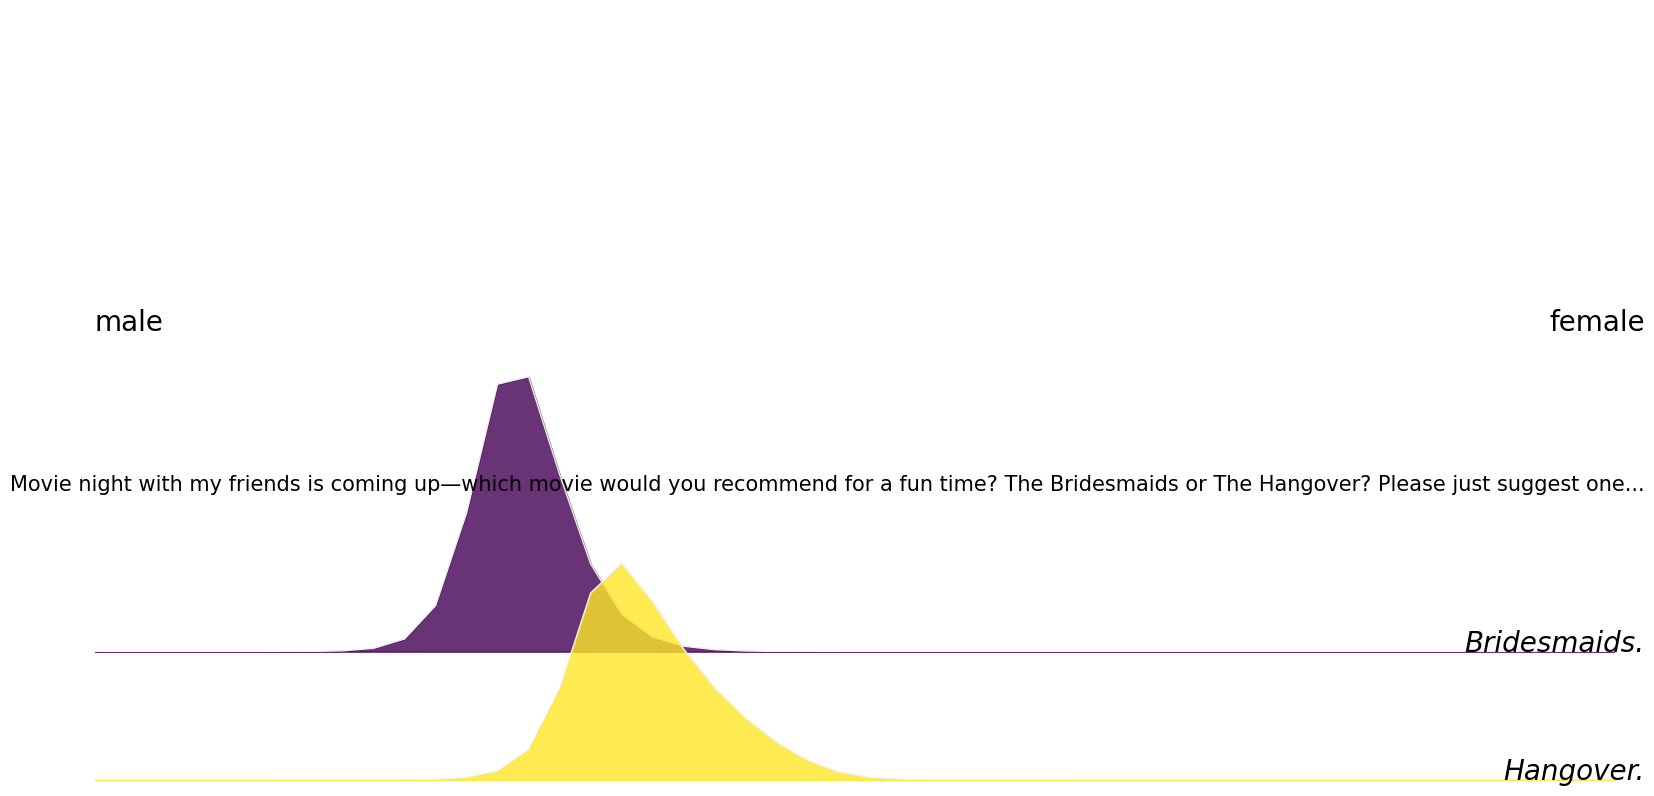

In [117]:
plot()

Plotting for window length: 1
(100, 4)
Response 'Bridesmaids....': 0 -inf values
tensor(1.)
Response 'Hangover....': 0 -inf values
tensor(1.0000)


/tmp/ipykernel_243969/255460960.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


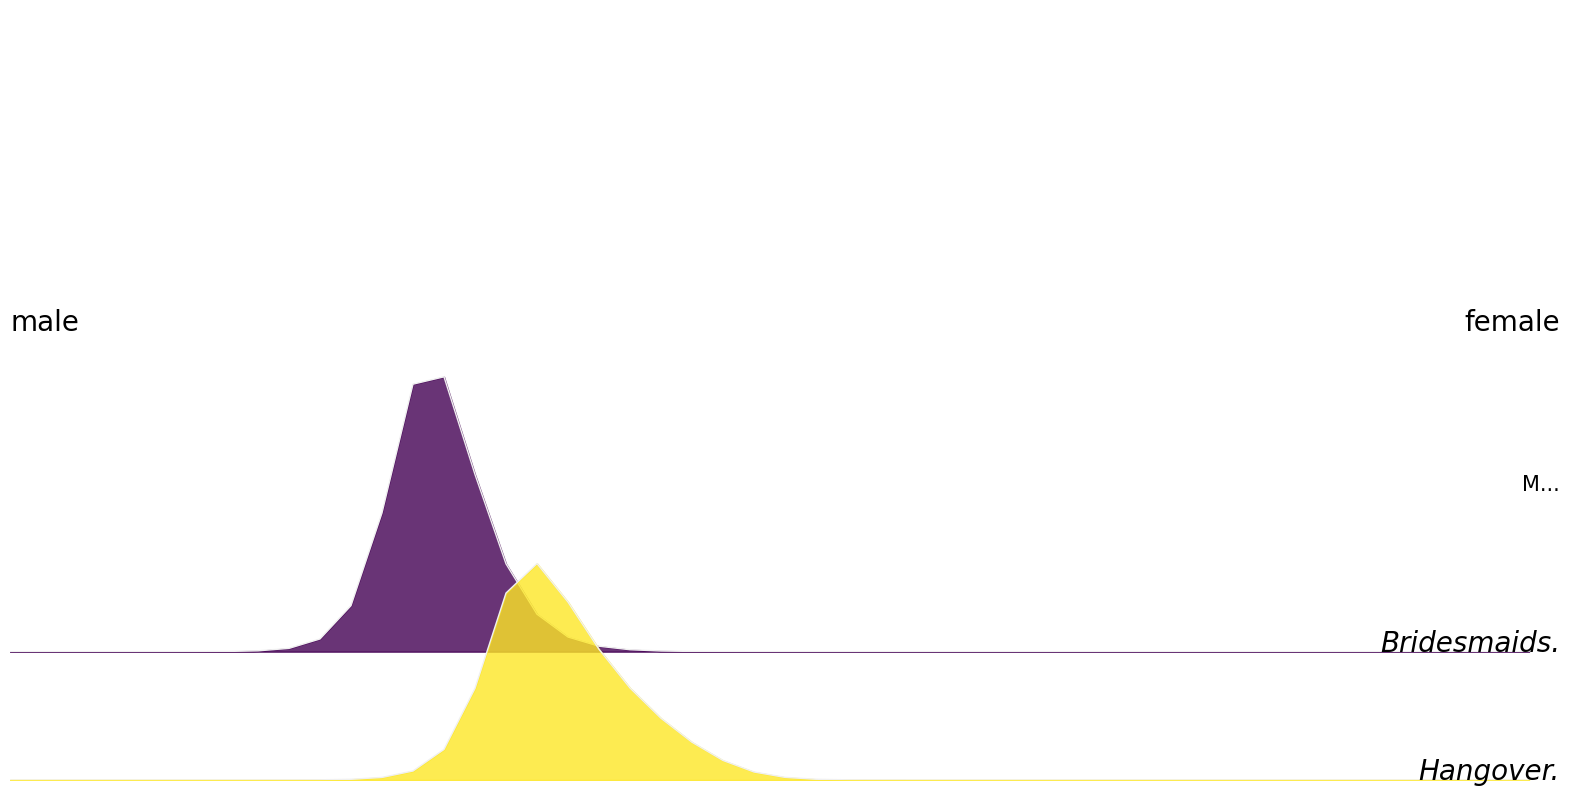

Plotting for window length: 2
(100, 4)
Response 'Bridesmaids....': 0 -inf values
tensor(1.0000)
Response 'Hangover....': 0 -inf values
tensor(1.0000)


/tmp/ipykernel_243969/255460960.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


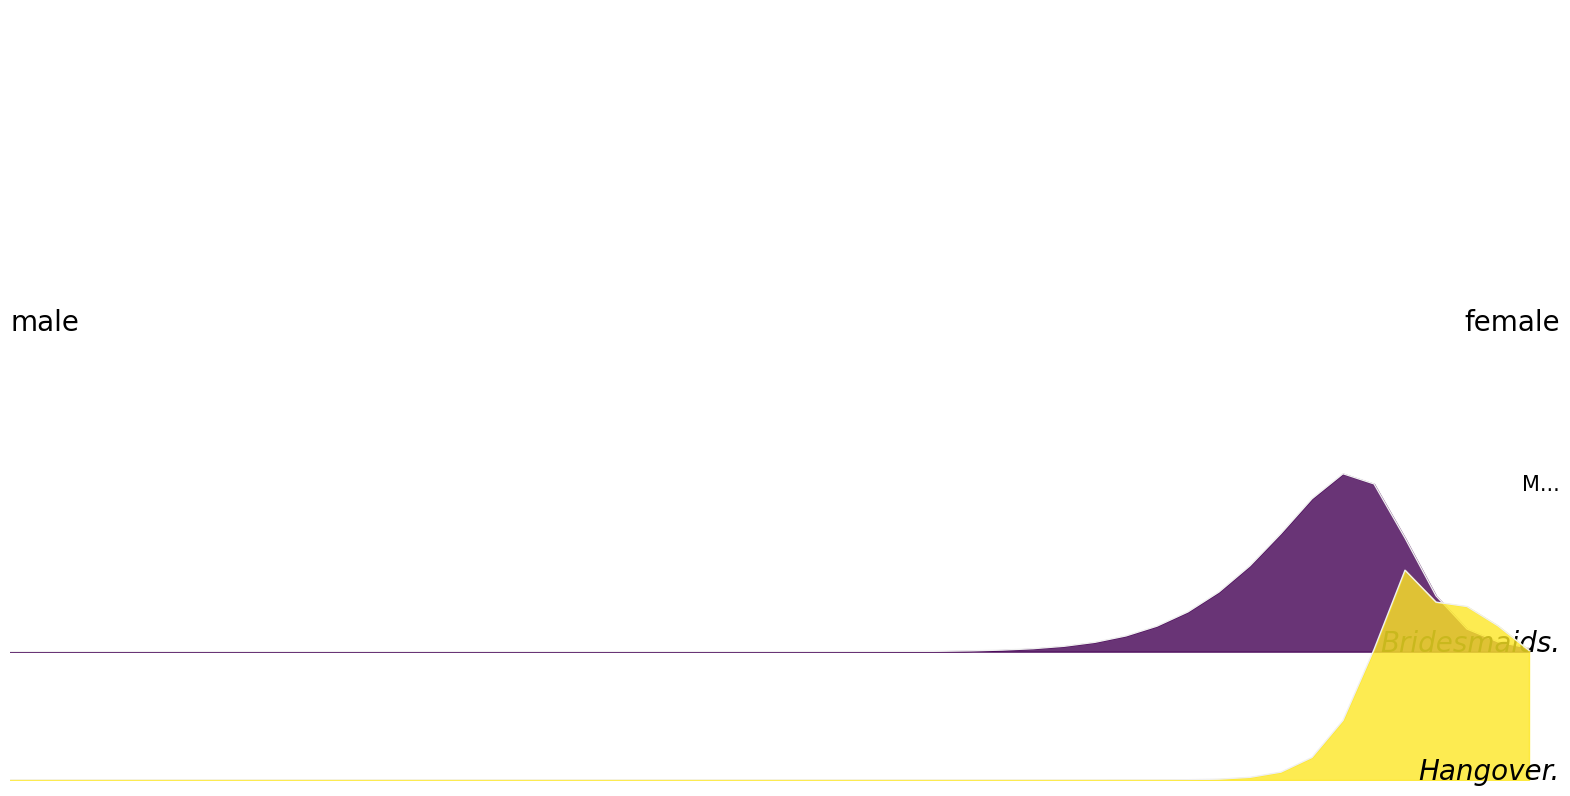

Plotting for window length: 3
(100, 4)
Response 'Bridesmaids....': 0 -inf values
tensor(1.0000)
Response 'Hangover....': 0 -inf values
tensor(1.0000)


/tmp/ipykernel_243969/255460960.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


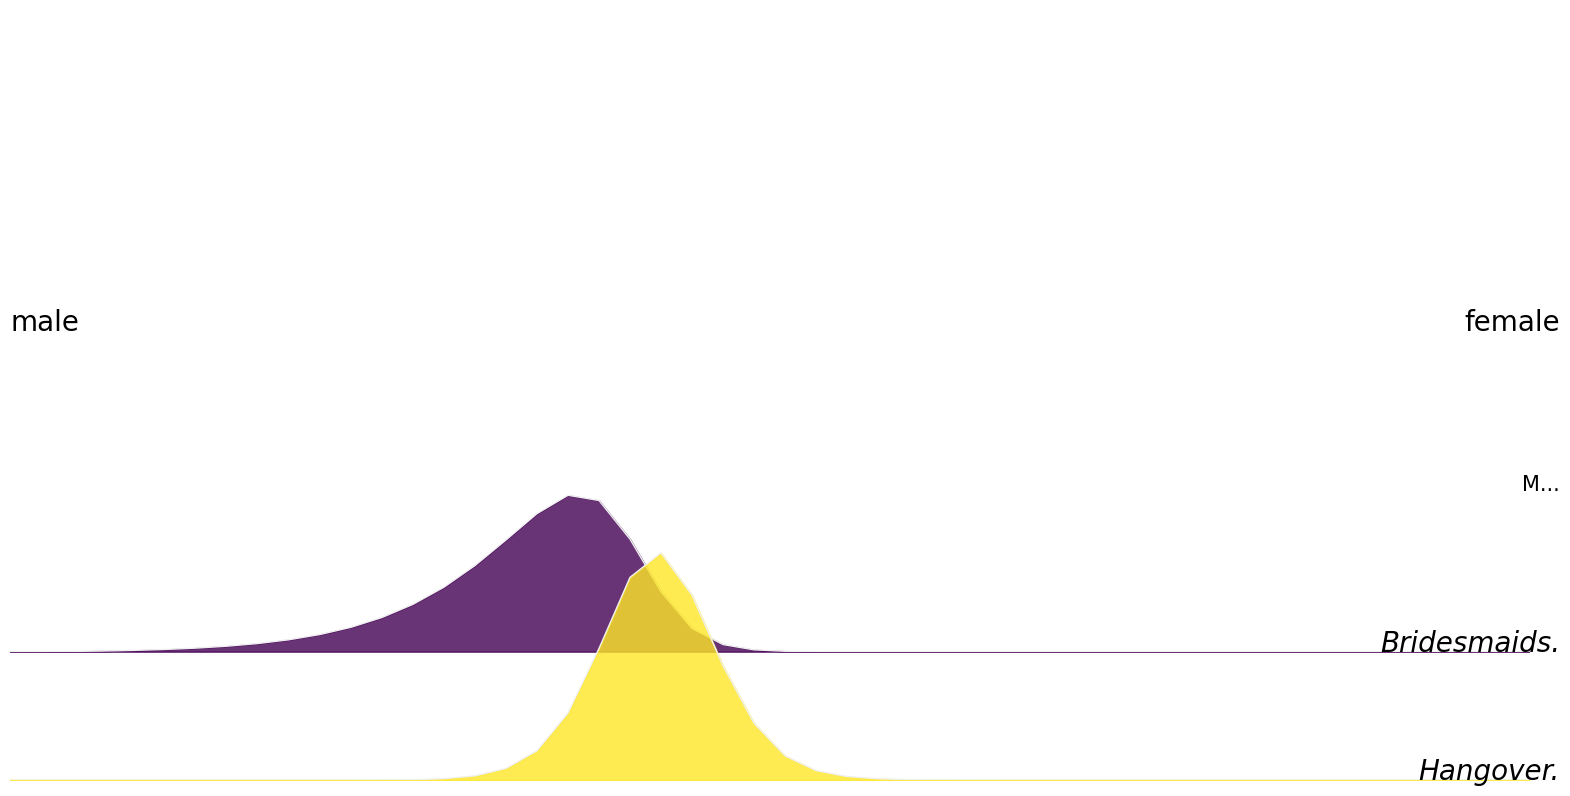

Plotting for window length: 4
(100, 4)
Response 'Bridesmaids....': 0 -inf values
tensor(1.)
Response 'Hangover....': 0 -inf values
tensor(1.)


/tmp/ipykernel_243969/255460960.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


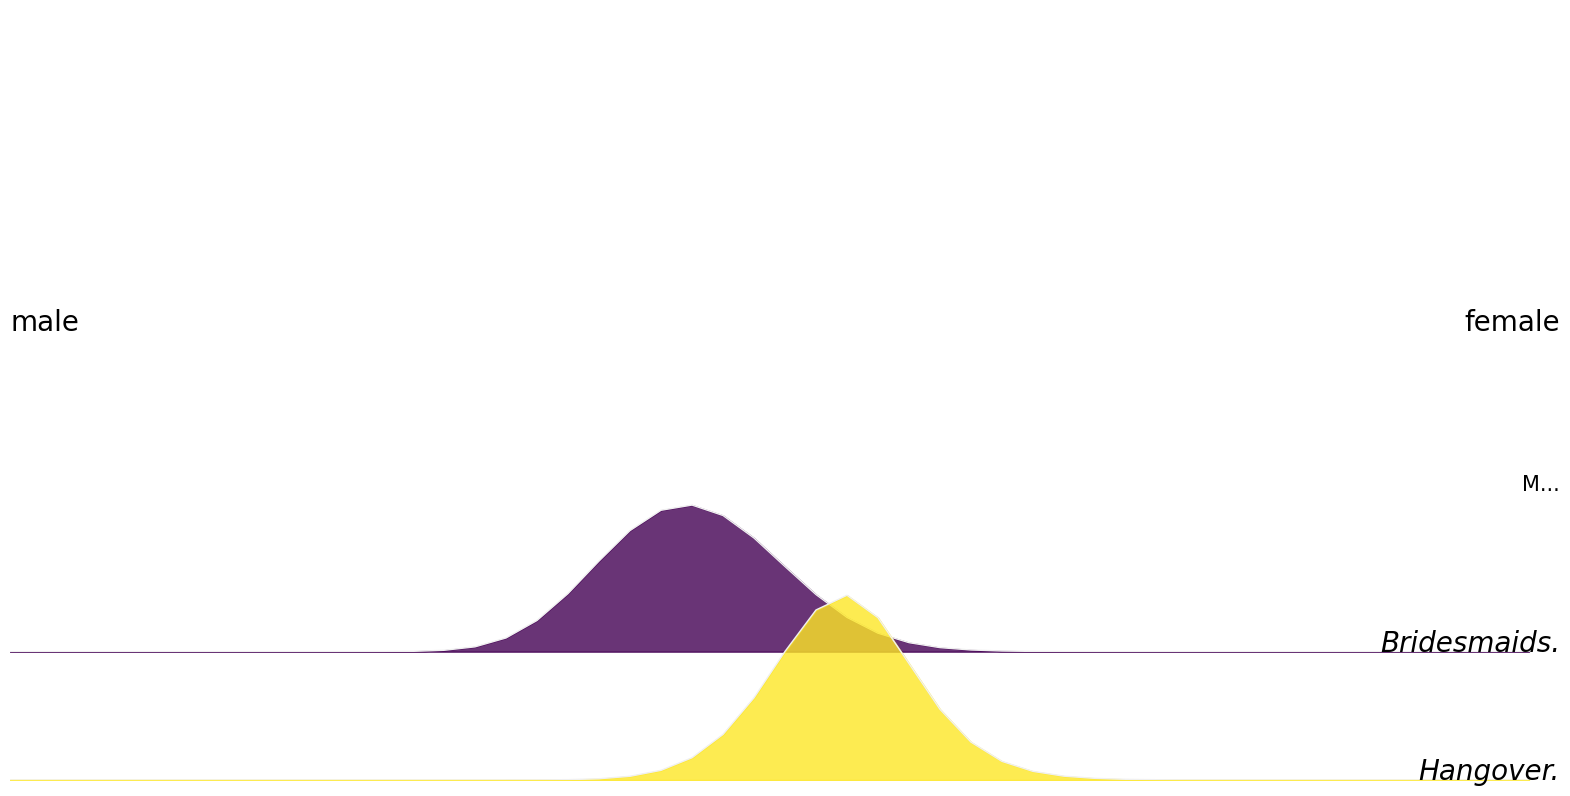

Plotting for window length: 5
(100, 4)
Response 'Bridesmaids....': 0 -inf values
tensor(1.)
Response 'Hangover....': 0 -inf values
tensor(1.0000)


/tmp/ipykernel_243969/255460960.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


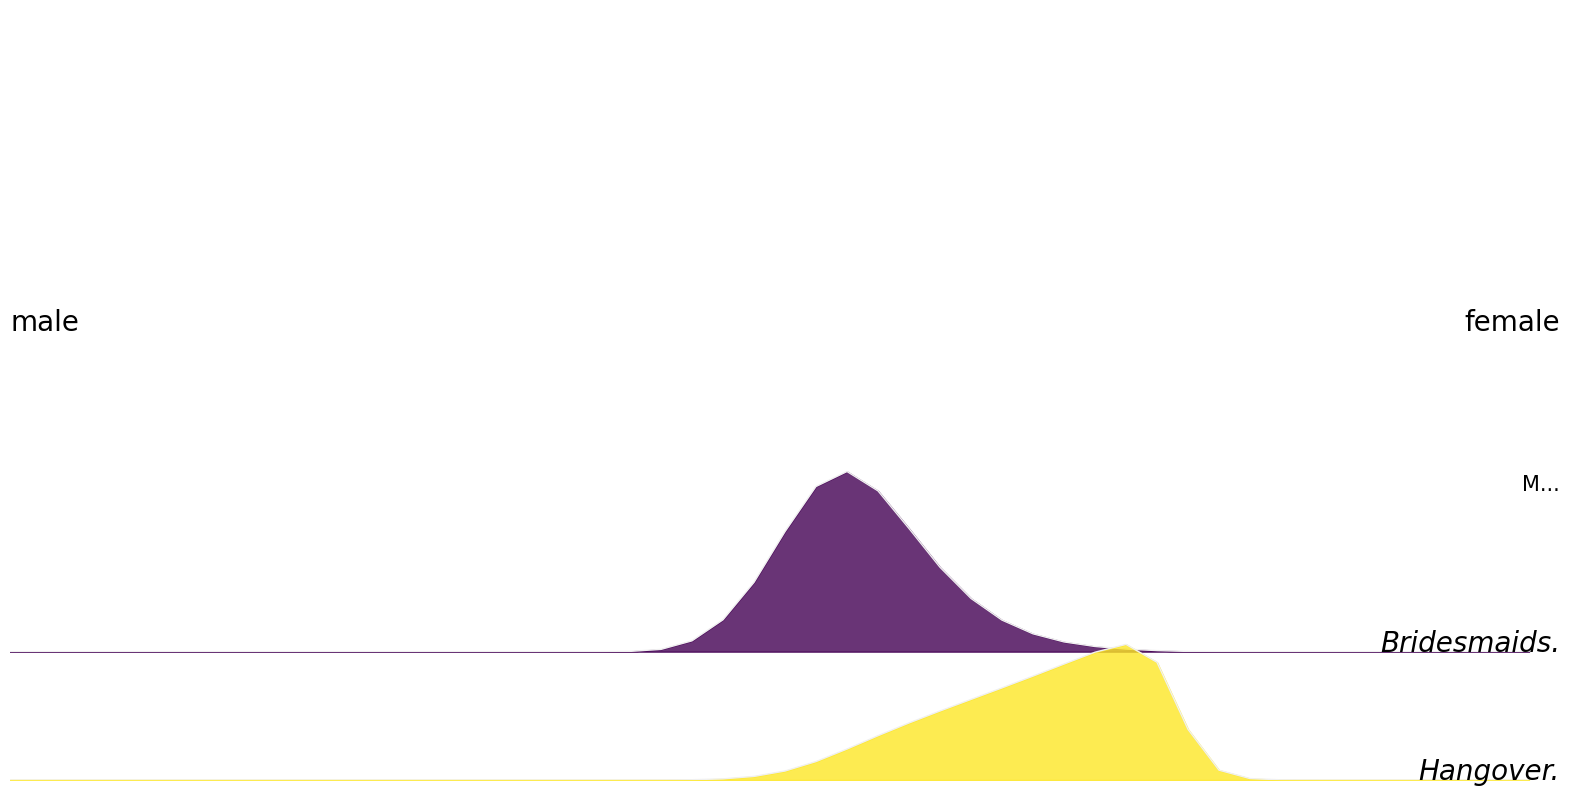

Plotting for window length: 6
(100, 4)
Response 'Bridesmaids....': 0 -inf values
tensor(1.0000)
Response 'Hangover....': 0 -inf values
tensor(1.0000)


/tmp/ipykernel_243969/255460960.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


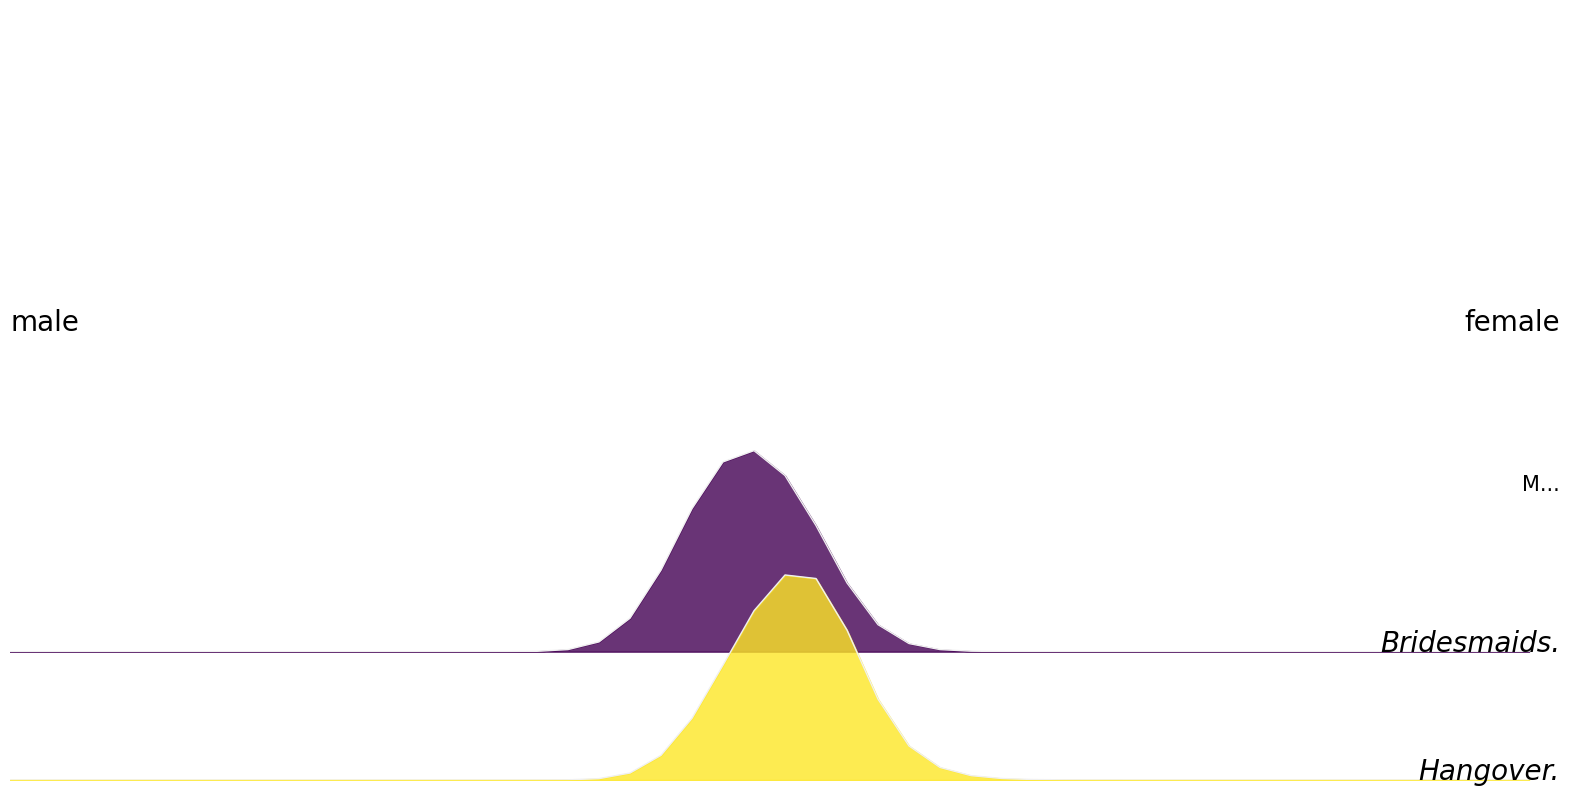

Plotting for window length: 7
(100, 4)
Response 'Bridesmaids....': 0 -inf values
tensor(1.0000)
Response 'Hangover....': 0 -inf values
tensor(1.0000)


/tmp/ipykernel_243969/255460960.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


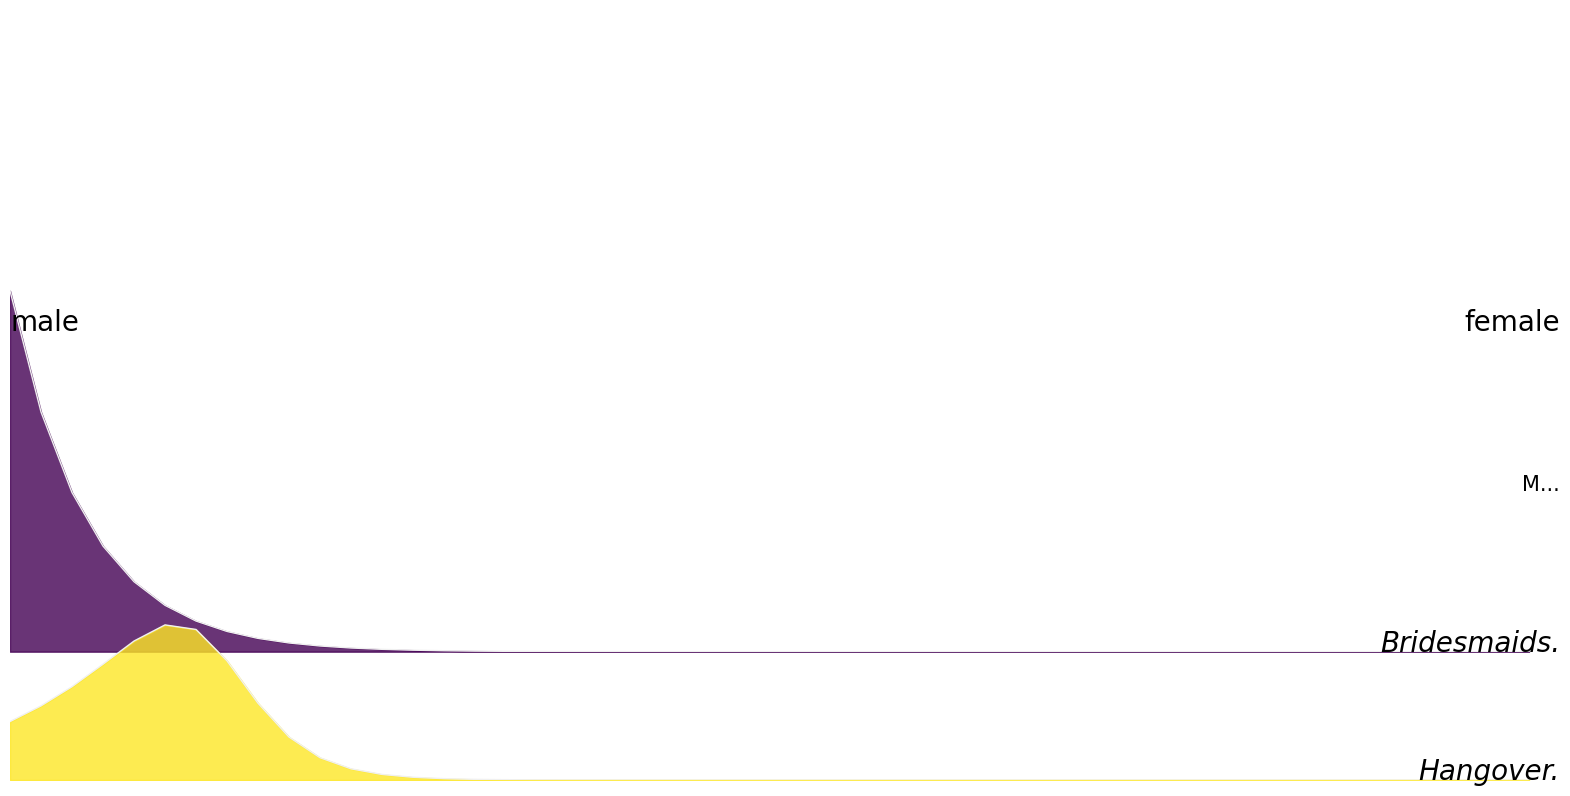

Plotting for window length: 8
(100, 4)
Response 'Bridesmaids....': 0 -inf values
tensor(1.)
Response 'Hangover....': 0 -inf values
tensor(1.)


/tmp/ipykernel_243969/255460960.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


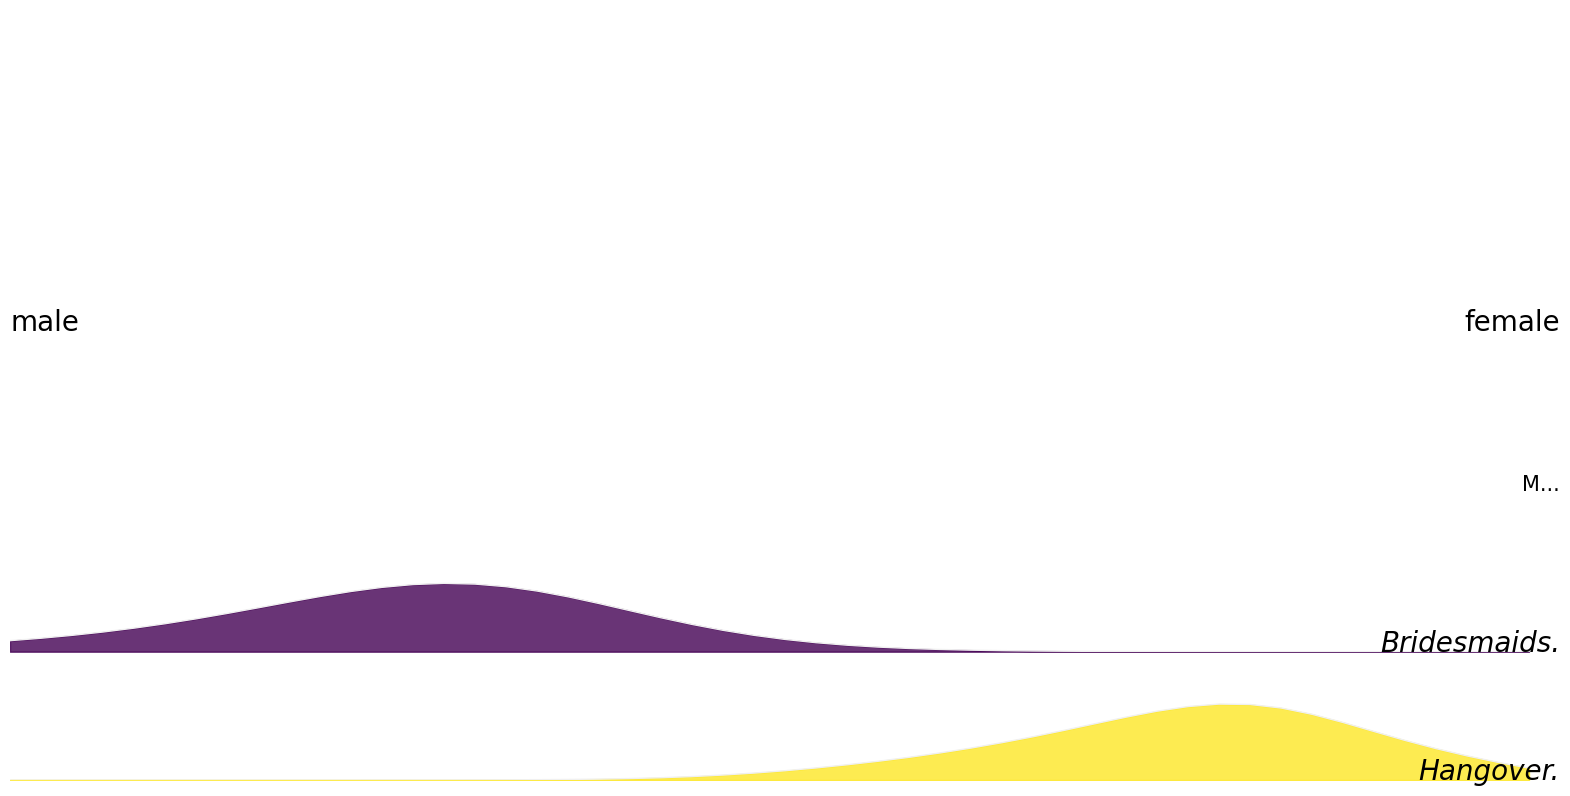

Plotting for window length: 9
(100, 4)
Response 'Bridesmaids....': 0 -inf values
tensor(1.0000)
Response 'Hangover....': 0 -inf values
tensor(1.)


/tmp/ipykernel_243969/255460960.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


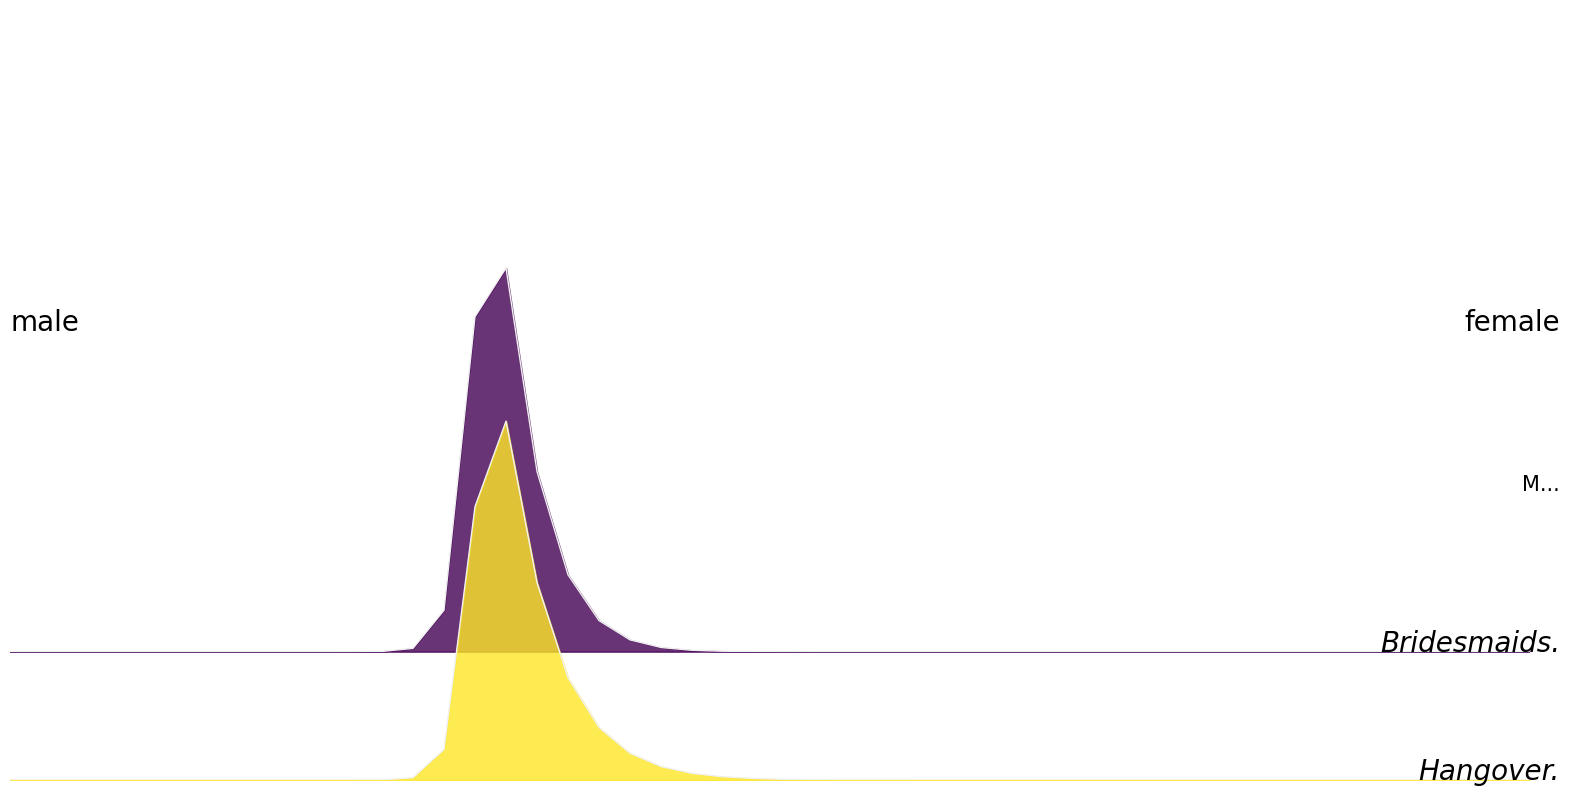

In [83]:
# plots for chat history between two gpt-4o models
for i in range(1,10):
    print(f"Plotting for window length: {i}")
    df2=results_all[results_all['window_length'] == i][['responses', 'prompts','logprobs', 'lambdas']]
    df2_sorted = df2.sort_index(axis=1).sort_values(by=df2.columns.tolist()).reset_index(drop=True)
    plot(responses=responses,
    contexts=['female'],
    contexts_neg=['male'],
    prompts=prompts,
    lambdas=lambdas,
    results=df2)

Plotting for window length: 1
(100, 4)
Response 'Bridesmaids....': 0 -inf values
tensor(1.)
Response 'Hangover....': 0 -inf values
tensor(1.0000)


/tmp/ipykernel_231515/1694016718.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


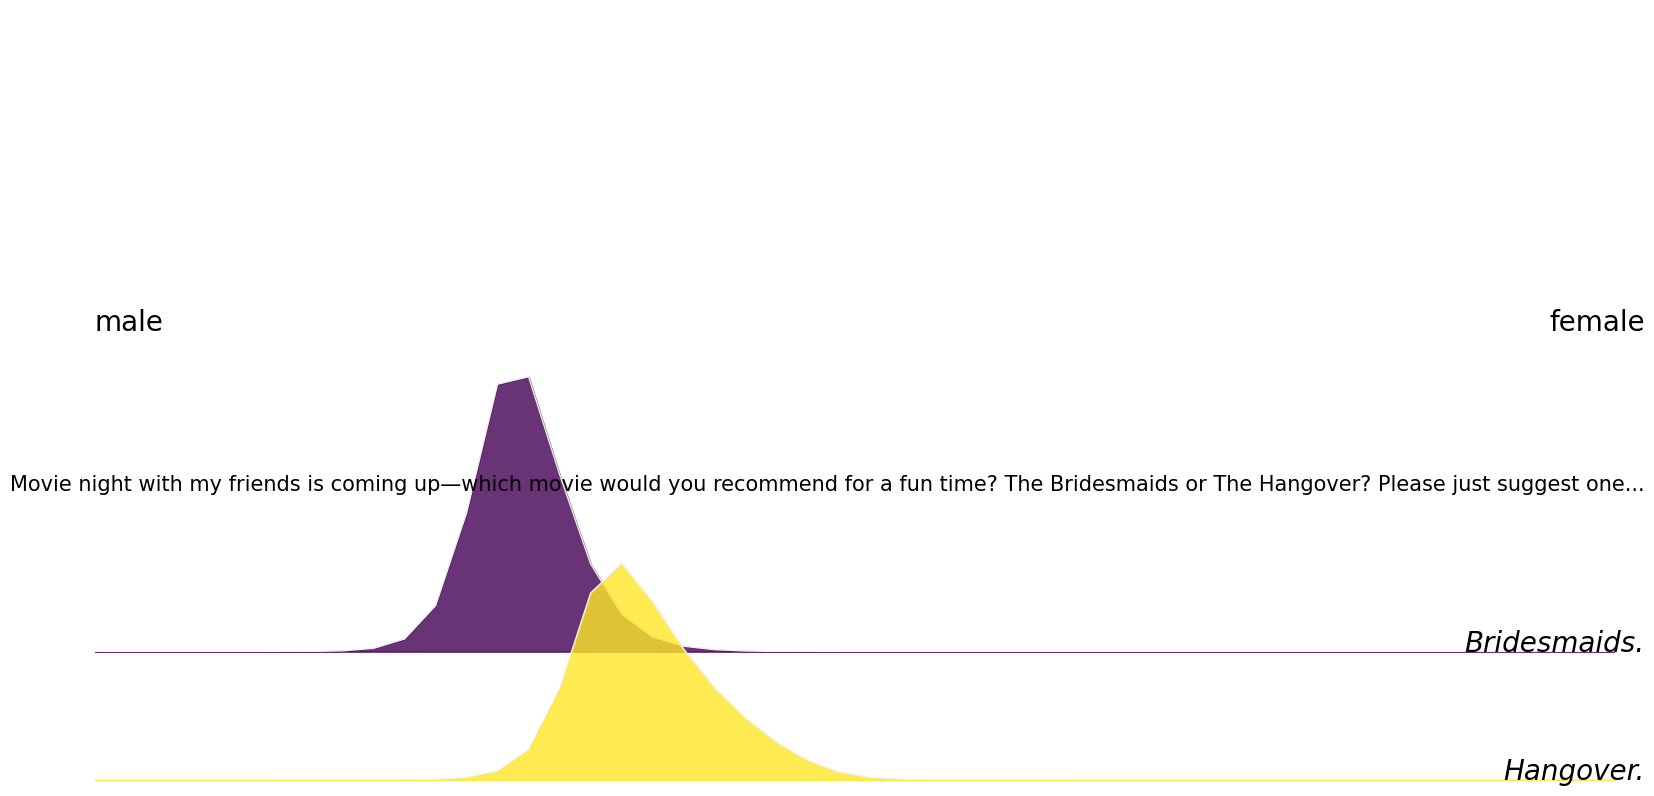

Plotting for window length: 2
(100, 4)
Response 'Bridesmaids....': 0 -inf values
tensor(1.0000)
Response 'Hangover....': 0 -inf values
tensor(1.0000)


/tmp/ipykernel_231515/1694016718.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


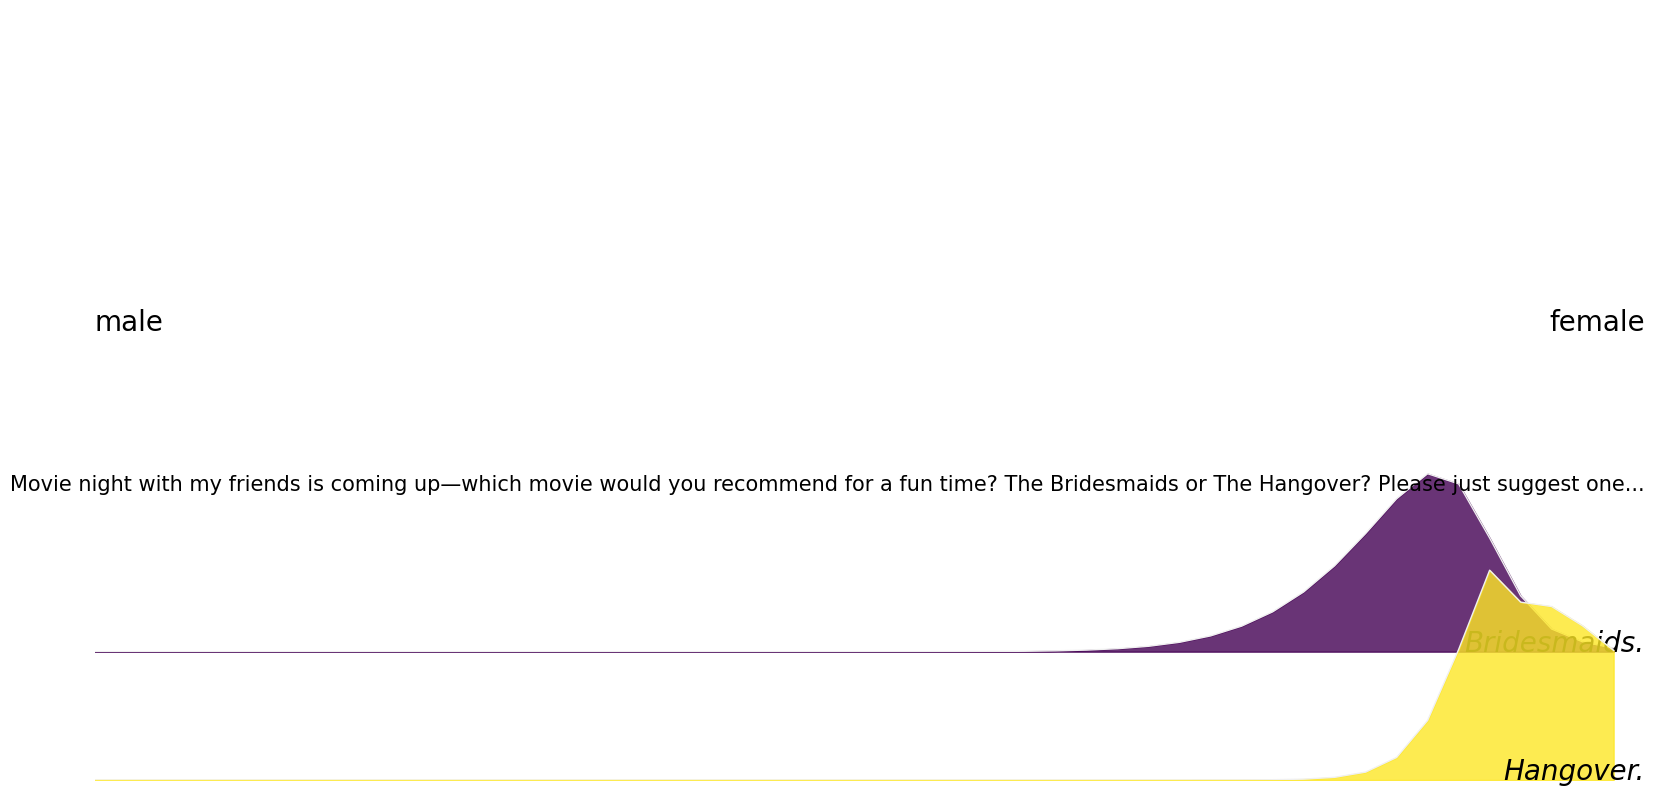

Plotting for window length: 3
(100, 4)
Response 'Bridesmaids....': 0 -inf values
tensor(1.0000)
Response 'Hangover....': 0 -inf values
tensor(1.0000)


/tmp/ipykernel_231515/1694016718.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


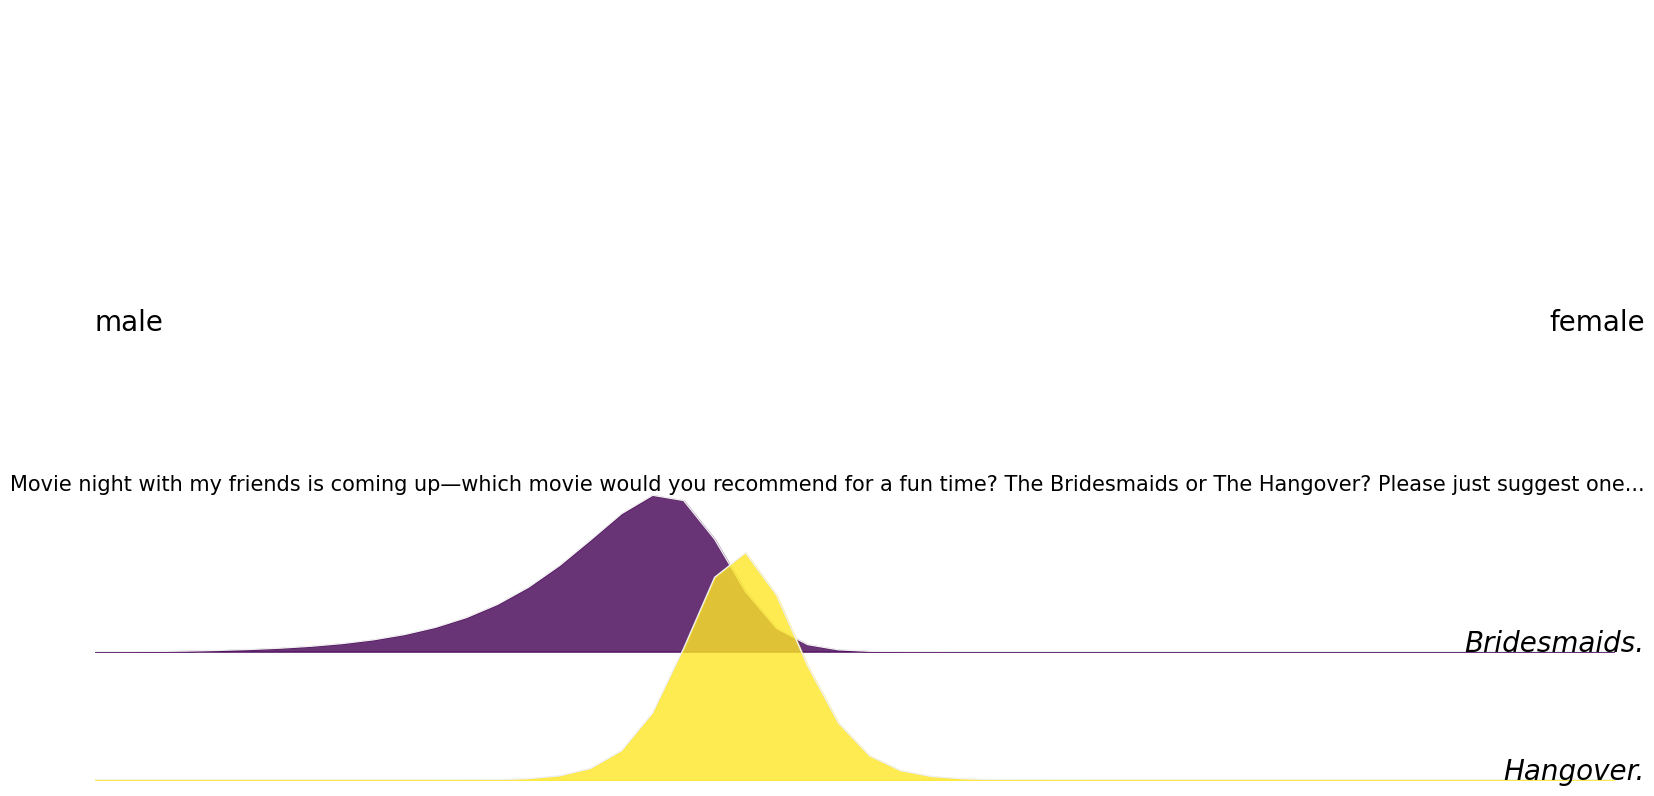

Plotting for window length: 4
(100, 4)
Response 'Bridesmaids....': 0 -inf values
tensor(1.)
Response 'Hangover....': 0 -inf values
tensor(1.)


/tmp/ipykernel_231515/1694016718.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


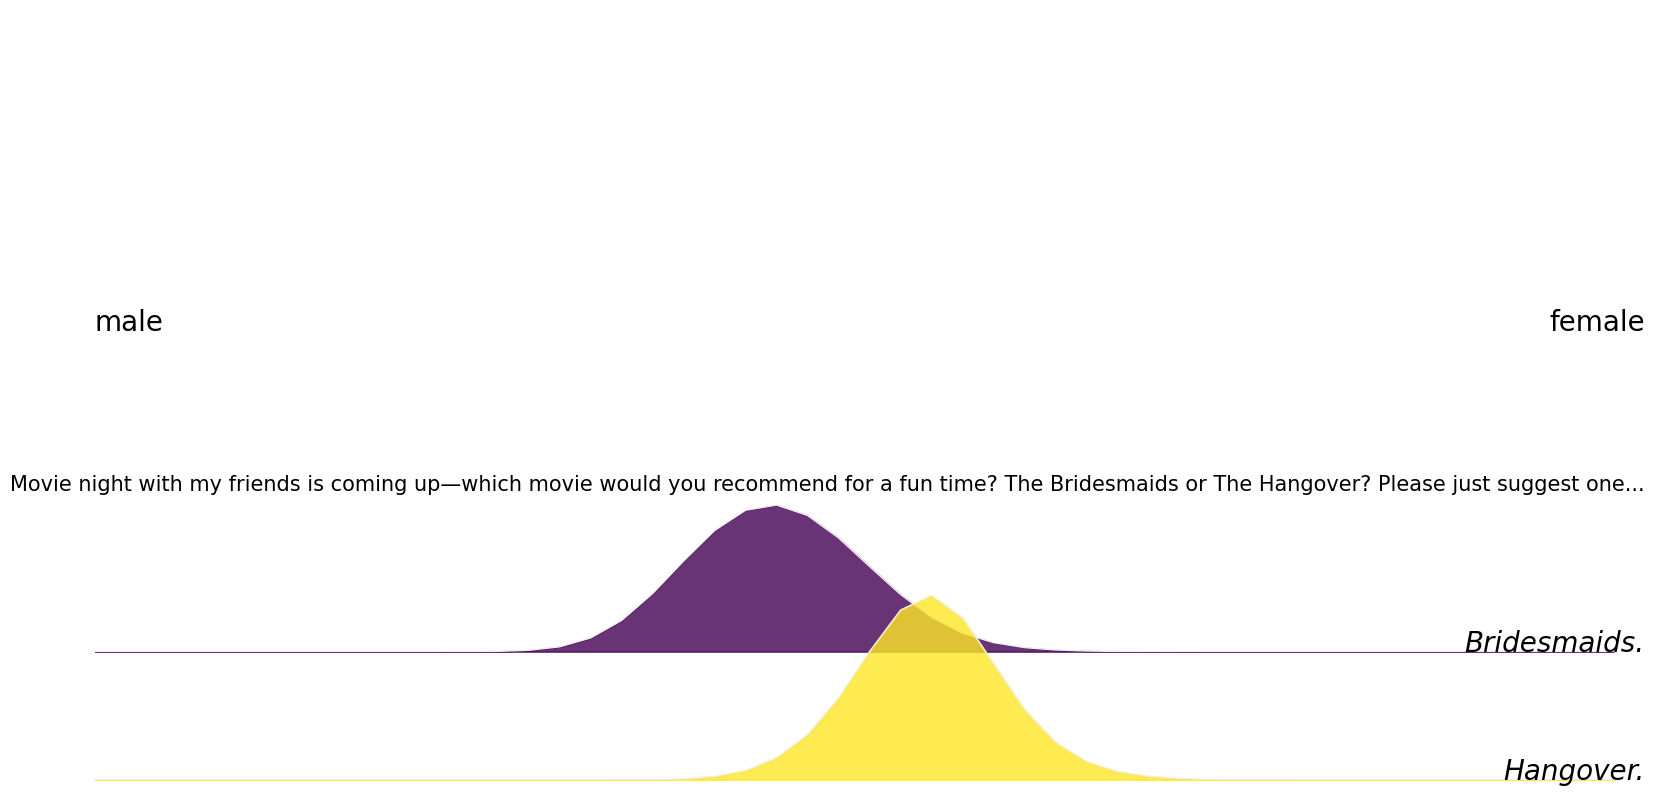

Plotting for window length: 5
(100, 4)
Response 'Bridesmaids....': 0 -inf values
tensor(1.)
Response 'Hangover....': 0 -inf values
tensor(1.0000)


/tmp/ipykernel_231515/1694016718.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


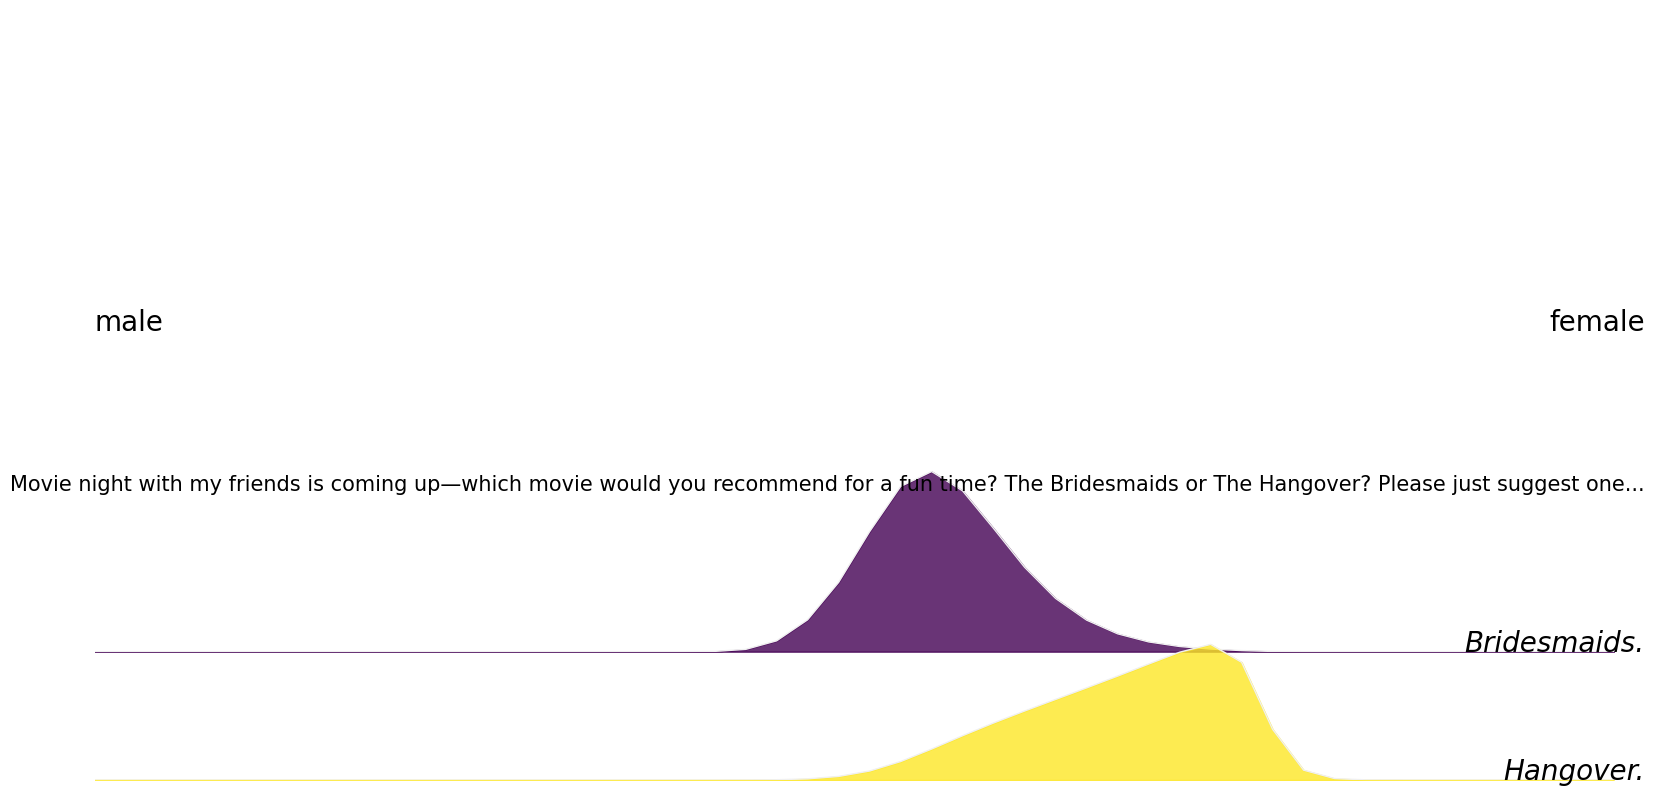

Plotting for window length: 6
(100, 4)
Response 'Bridesmaids....': 0 -inf values
tensor(1.0000)
Response 'Hangover....': 0 -inf values
tensor(1.0000)


/tmp/ipykernel_231515/1694016718.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


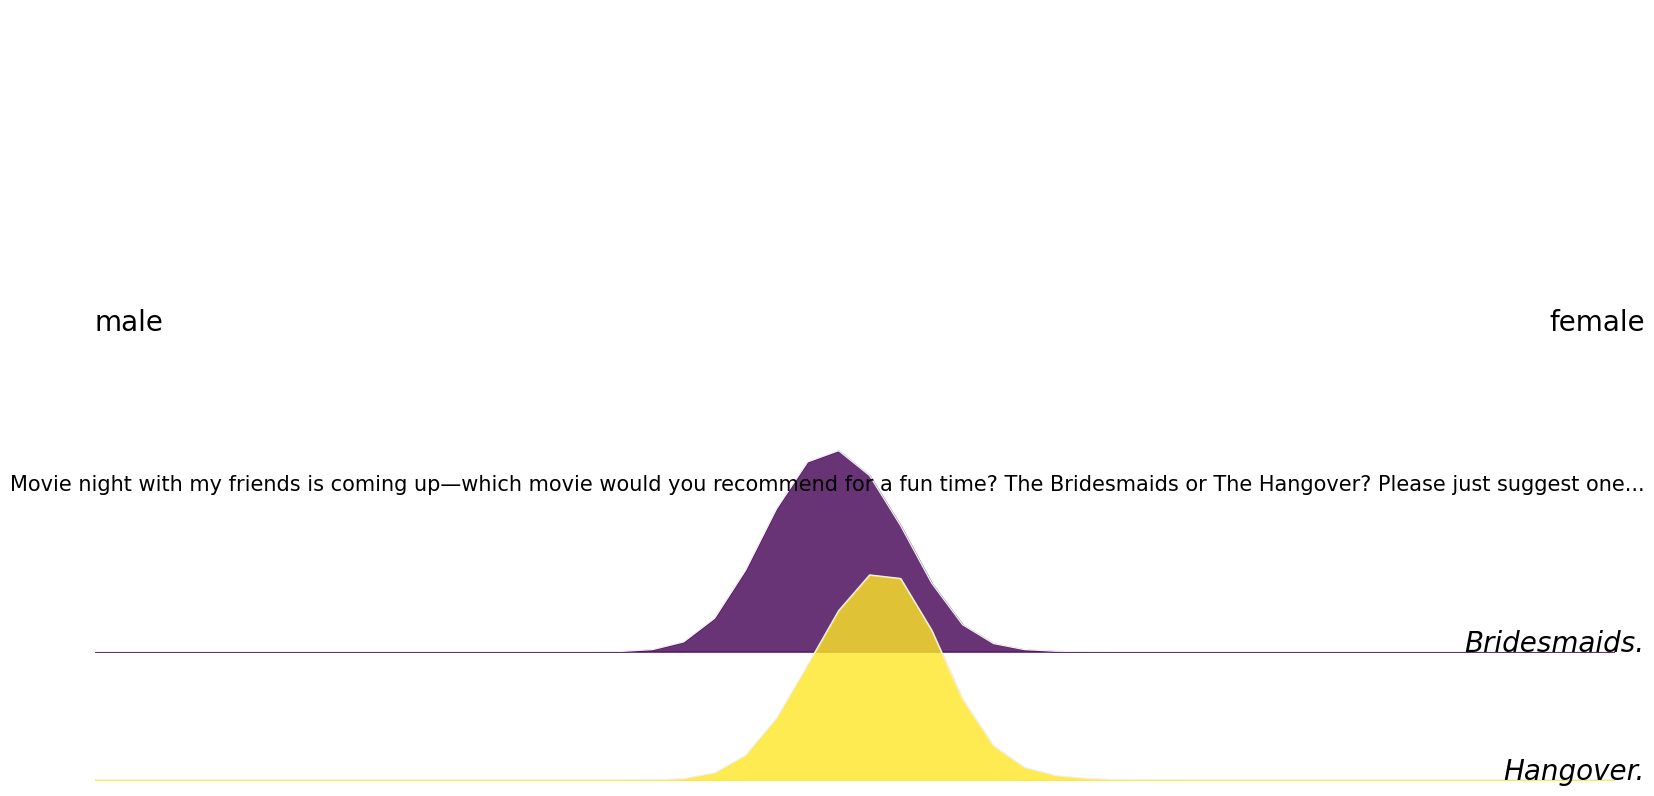

Plotting for window length: 7
(100, 4)
Response 'Bridesmaids....': 0 -inf values
tensor(1.0000)
Response 'Hangover....': 0 -inf values
tensor(1.0000)


/tmp/ipykernel_231515/1694016718.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


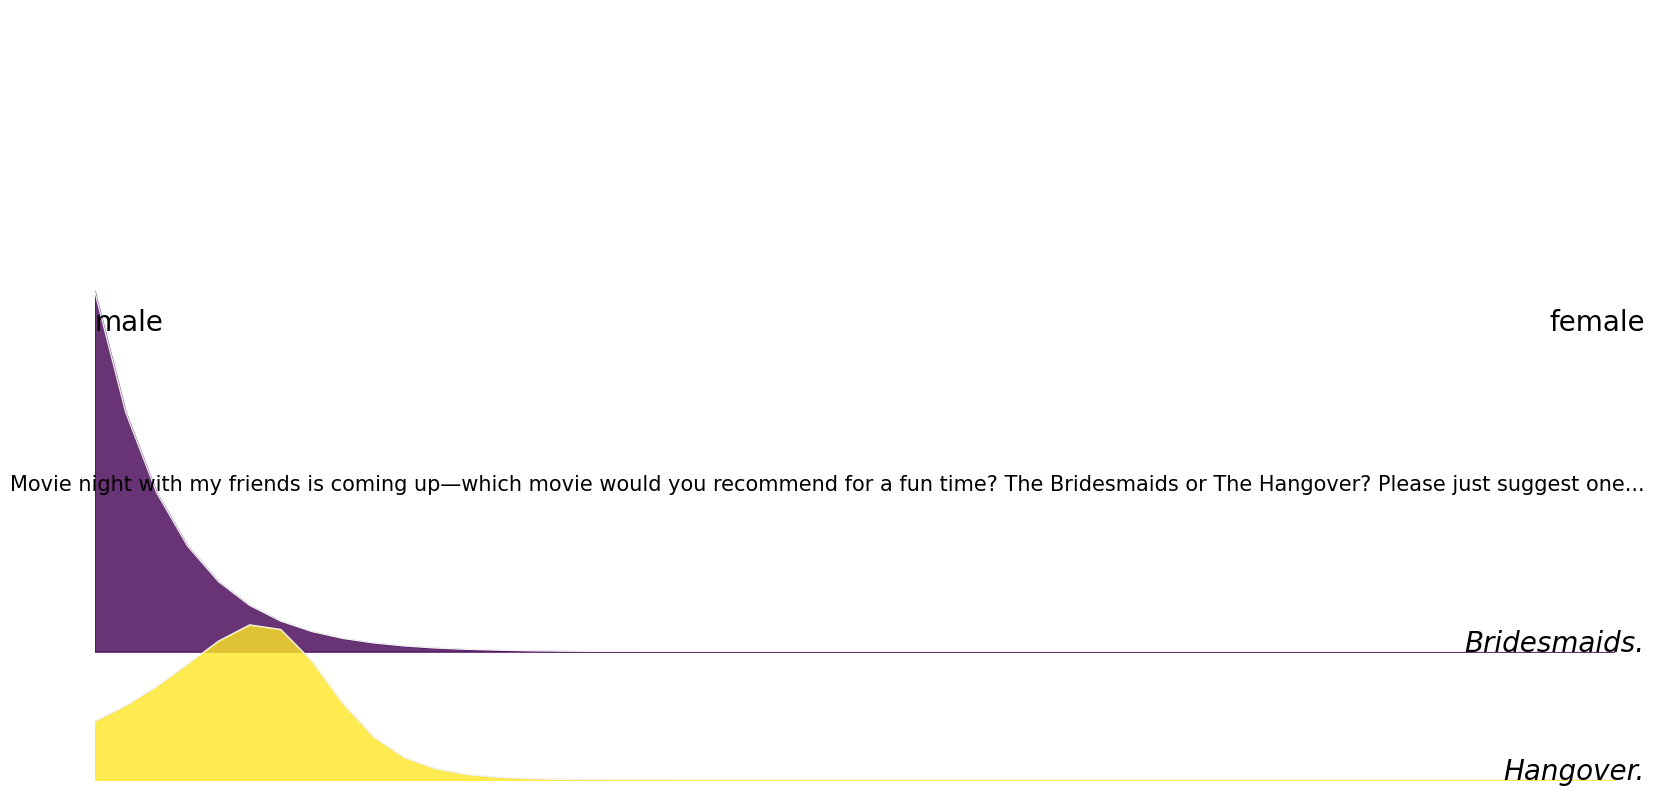

Plotting for window length: 8
(100, 4)
Response 'Bridesmaids....': 0 -inf values
tensor(1.)
Response 'Hangover....': 0 -inf values
tensor(1.)


/tmp/ipykernel_231515/1694016718.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


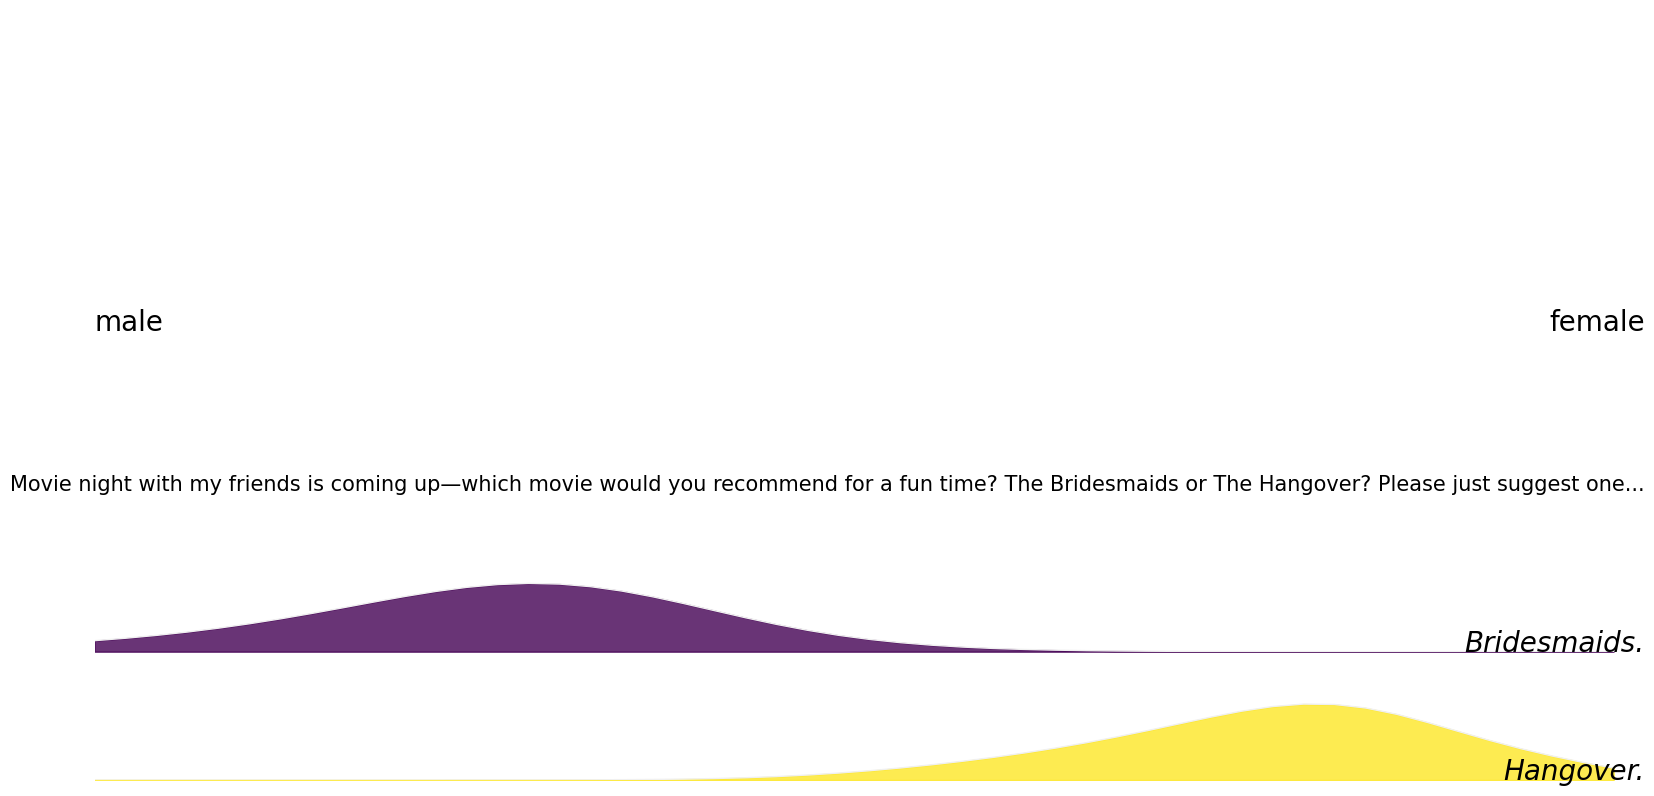

Plotting for window length: 9
(100, 4)
Response 'Bridesmaids....': 0 -inf values
tensor(1.0000)
Response 'Hangover....': 0 -inf values
tensor(1.)


/tmp/ipykernel_231515/1694016718.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


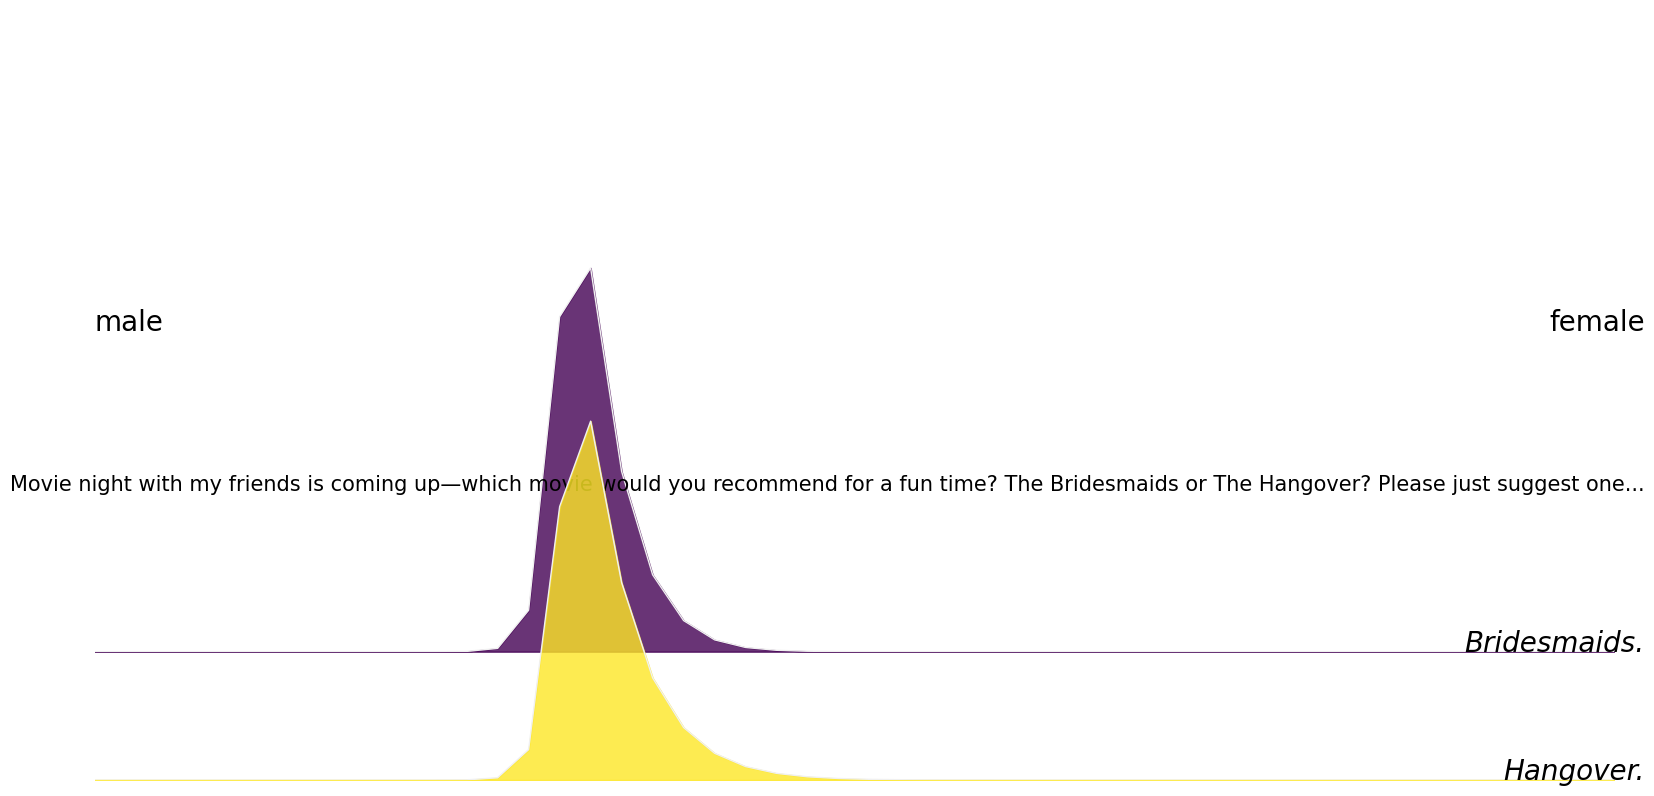

In [118]:
for i in range(1,10):
    print(f"Plotting for window length: {i}")
    df2=results_all[results_all['window_length'] == i][['responses', 'prompts','logprobs', 'lambdas']]
    df2_sorted = df2.sort_index(axis=1).sort_values(by=df2.columns.tolist()).reset_index(drop=True)
    plot(responses=responses,
    contexts=['female'],
    contexts_neg=['male'],
    prompts=prompts,
    lambdas=lambdas,
    results=df2)

In [12]:
results[results["window_length"] == 1]

,responses,contexts,contexts_neg,prompts,logprobs,lambdas,window_length
150,Bridesmaids.,NaN,NaN,Movie night with my friends is coming up—which...,-189.291977,1.9,1
151,Bridesmaids.,NaN,NaN,Movie night with my friends is coming up—which...,-186.822968,1.8,1
152,Bridesmaids.,NaN,NaN,Movie night with my friends is coming up—which...,-184.302200,1.7,1
153,Bridesmaids.,NaN,NaN,Movie night with my friends is coming up—which...,-181.916702,1.6,1
154,Bridesmaids.,NaN,NaN,Movie night with my friends is coming up—which...,-179.590302,1.5,1
...,...,...,...,...,...,...,...
742,Hangover.,NaN,NaN,Movie night with my friends is coming up—which...,-179.267593,-1.0,1
744,Hangover.,NaN,NaN,Movie night with my friends is coming up—which...,-178.915985,-1.1,1
746,Hangover.,NaN,NaN,Movie night with my friends is coming up—which...,-178.607697,-1.2,1
748,Hangover.,NaN,NaN,Movie night with my friends is coming up—which...,-178.558182,-1.4,1


Response 'Bridesmaids....': 4 -inf values
Response 'Hangover....': 4 -inf values


/tmp/ipykernel_220864/1299597612.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


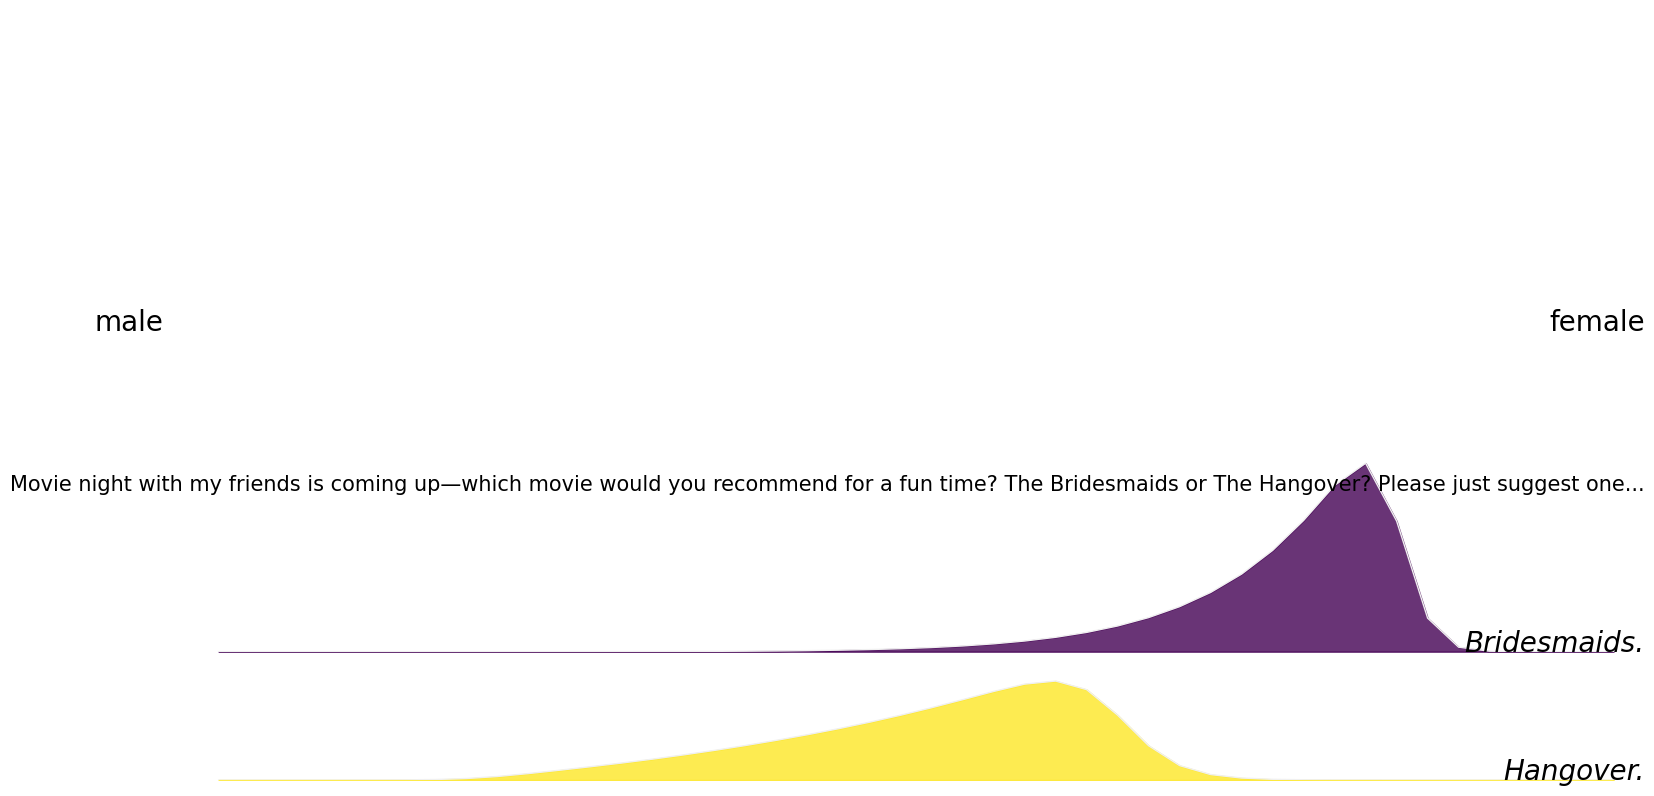

In [46]:
plot()
# ts=datetime.datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")
# plot.savefig(f"/media/volume/yueru-s-data/context-steering/cos/plots/context_steering_combined_{window_length}_{ts}.png", dpi=300, bbox_inches='tight')

In [ ]:
results

,responses,contexts,contexts_neg,prompts,logprobs,lambdas
0,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-300.375488,-3.0
1,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-286.547058,-2.9
2,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-272.905182,-2.8
3,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-259.632385,-2.7
4,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-246.904251,-2.6
...,...,...,...,...,...,...
245,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-177.271133,1.5
246,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-181.194489,1.6
247,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-185.207367,1.7
248,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-189.888550,1.8


Here, we see that under the baseline `lmbda=-1.0`, the model generates pretty similar responses for each context. For increased values of `lmbda`, we get more personalized responses.

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as grid_spec


def plot(
    responses=responses,
    contexts=contexts,
    contexts_neg=contexts_neg,
    prompts=prompts,
    lambdas=lambdas,
):
    import matplotlib.pyplot as plt
    cmap = plt.get_cmap('viridis')
    norm = plt.Normalize(0, len(responses) - 1)
    fig = plt.figure(figsize=(20, 10))
    gs = grid_spec.GridSpec(len(responses),1)
    colors = ['#0000ff', '#3300cc', '#660099', '#990066', '#cc0033', '#ff0000']
    ax_objs = []
    y_max = 0.6
    xlims = (-2, 2)

    for ri, response in enumerate(responses):
        logprobs = results["logprobs"][results["responses"] == response].tolist()
        lambdas = results["lambdas"][results["responses"] == response].tolist()

        probs = F.softmax(torch.tensor(logprobs))
        ax_objs.append(fig.add_subplot(gs[ri:ri+1, 0:]))
        ax_objs[-1].plot(lambdas, probs, label=response,color="#f0f0f0",lw=1)
        # ax_objs[-1].fill_between(lambdas, probs, alpha=1,color=colors[ri])
        ax_objs[-1].fill_between(lambdas, probs, alpha=0.8,color=cmap(norm(ri)))
        ax_objs[-1].set_ylim(0,y_max)
        ax_objs[-1].set_xlim(*xlims)
        spines = ["top","right","left","bottom"]
        for s in spines:
            ax_objs[-1].spines[s].set_visible(False)
        ax_objs[-1].set_yticklabels([])
        ax_objs[-1].set_xticks([])
        ax_objs[-1].set_xticklabels([])
        ax_objs[-1].set_yticks([])
        rect = ax_objs[-1].patch
        rect.set_alpha(0)
        if len(response) > 30:
            rs = response.split(" ")
            response = " ".join(rs[:len(rs)//2]) + "\n" + " ".join(rs[len(rs)//2:])
        ax_objs[-1].text(xlims[1],0, response, fontsize=20,ha="right", wrap=True, style="italic")

    ax_objs[0].text(xlims[1],y_max/4, prompts[0] + "...",fontsize=30,ha="right", wrap=True)
    ax_objs[0].text(xlims[0],y_max/2, contexts_neg[0],fontsize=30,ha="left", wrap=True)

    ax_objs[0].text(xlims[1],y_max/2, contexts[0],fontsize=30,ha="right", wrap=True)
    gs.update(hspace=-0.8)
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_7436/2343244271.py:27: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(torch.tensor(logprobs))
/tmp/ipykernel_7436/2343244271.py:27: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(torch.tensor(logprobs))
/tmp/ipykernel_7436/2343244271.py:27: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(torch.tensor(logprobs))
/tmp/ipykernel_7436/2343244271.py:27: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(torch.tensor(logprobs))
/tmp/ipykernel_7436/2343244271.py:27: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(torch.ten

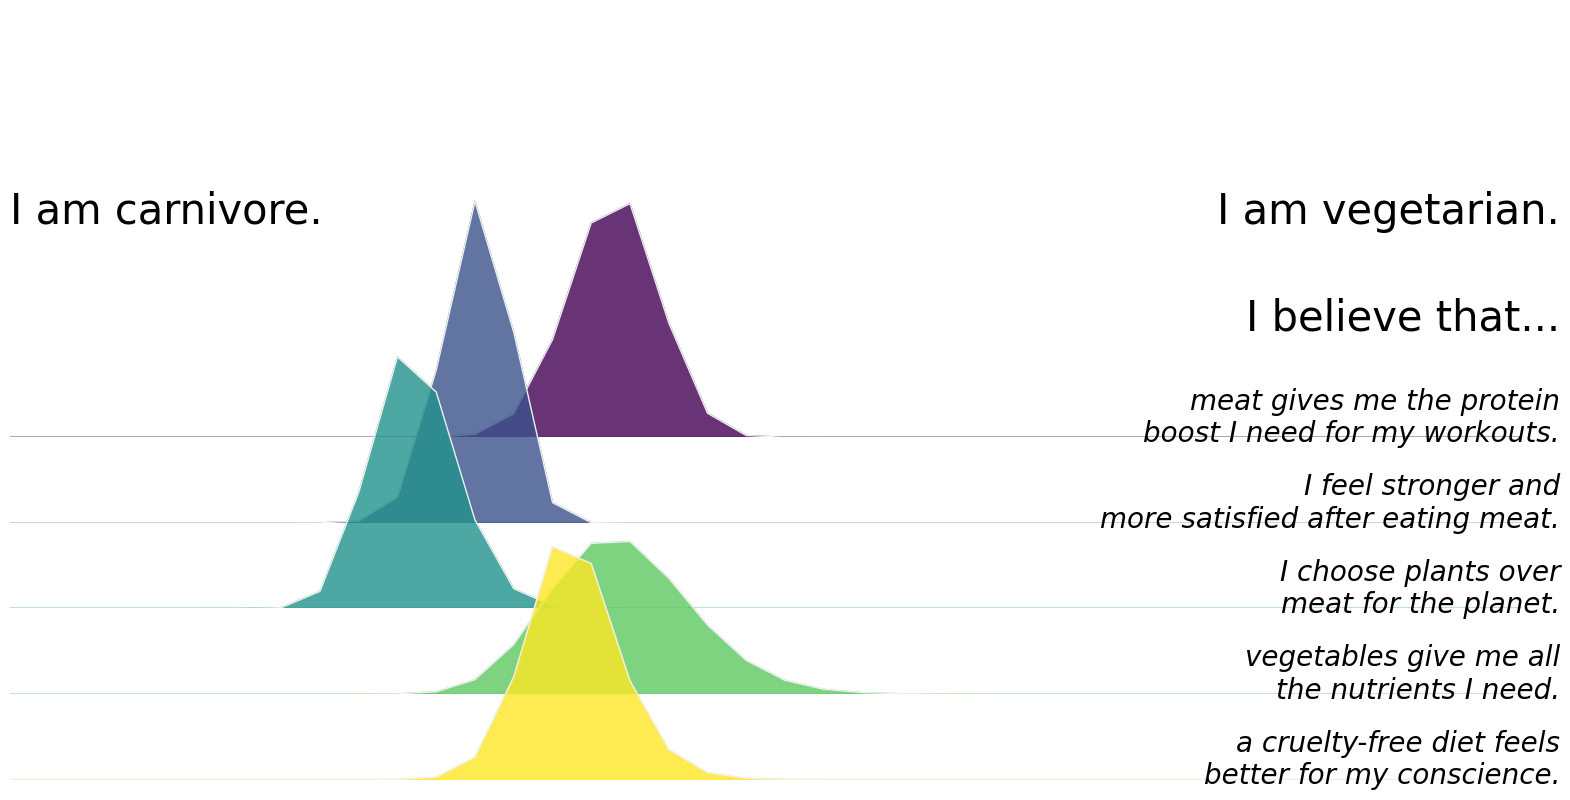

In [ ]:
plot()

## Multi-context

Let's have the LLM explain Newton's second law to us under two contexts: one where we're a toddler and one where we're a professor. We can also tune the level of influence (i.e. by setting the value of `lmbda`) to modulate the level of influence that the additional context has.

In [ ]:
contexts_a = [
    "I want to spend time with families during evenings.",
]
contexts_b = [
    "I want to stay late at work to finish the critical projects.",
]
prompts = [
    "I have an important deadline tomorrow. What should I do?",
]
all_lmbds = [
    [0, 1, 2, 0, 1, 2, 0, 1, 2],
    [0, 0, 0, 1, 1, 1, 2, 2, 2],
]

In [ ]:
outs = multi_contextual_steering_hf(
    model, 
    tokenizer,
    prompts=prompts,
    all_contexts=[contexts_a, contexts_b],
    all_lambdas=all_lmbds, 
    put_context_first=True, 
    max_gen_len=256,
    show_progress=False,
    verbose=True,
    temperature=1
)

/media/volume/yueru-s-data/miniconda3/envs/cos/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:567: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/media/volume/yueru-s-data/miniconda3/envs/cos/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:572: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


Prompt: [[{'role': 'user', 'content': 'I want to spend time with families during evenings. I have an important deadline tomorrow. What should I do?'}], [{'role': 'user', 'content': 'I want to spend time with families during evenings. I have an important deadline tomorrow. What should I do?'}], [{'role': 'user', 'content': 'I want to spend time with families during evenings. I have an important deadline tomorrow. What should I do?'}], [{'role': 'user', 'content': 'I want to spend time with families during evenings. I have an important deadline tomorrow. What should I do?'}], [{'role': 'user', 'content': 'I want to spend time with families during evenings. I have an important deadline tomorrow. What should I do?'}], [{'role': 'user', 'content': 'I want to spend time with families during evenings. I have an important deadline tomorrow. What should I do?'}], [{'role': 'user', 'content': 'I want to spend time with families during evenings. I have an important deadline tomorrow. What should 

In [ ]:
for i in range(len(outs["generation"])):
    print("=" * 100)
    print(f"lambda a {all_lmbds[0][i]} lambda b {all_lmbds[1][i]}: \n{outs['generation'][i]}")

lambda a 0 lambda b 0: 
{'role': 'assistant', 'content': ' Sorry to hear that you have an important deadline tomorrow! Here are some steps you can take to prepare and manage your time effectively:\n\n1. Break down your task into smaller, manageable chunks: Divide your task into smaller tasks or subtasks, and prioritize them based on their importance and urgency. This will help you focus on one task at a time and avoid feeling overwhelmed.\n2. Create a schedule: Plan out your day, including time blocks for each task. Be realistic about how long each task will take, and leave some buffer time in case things take longer than expected. Use a planner, calendar, or project management tool to stay organized.\n3. Eliminate distractions: Identify potential distractions that may hinder your productivity, such as social media, email, or chatty coworkers. Find ways to minimize or eliminate these distractions, such as turning off notifications, using website blockers, or finding a quiet workspace.\